# Encoder transform analysis — data-only metrics on **all** layer-0 q_proj blocks

Same model (`nwc_ql`, M=16, encdim=512, Q=4) and same kind of analysis as `plot_encoder_function2.ipynb`,
but with two changes:

1. **Data**: Llama-3-8B **layer 0** `self_attn.q_proj.weight`, *all* $4096 \times 4096 / 16 = 1{,}048{,}576$
   16-dim blocks — **no random subsampling**.
2. **No Jacobians.** All metrics (orthogonality, max-to-mean, participation ratio, distance to RHT)
   are computed purely from $(X, Z)$ pairs via the empirical linear Jacobian
   $\hat J_\text{emp} = \Sigma_{zx}\,\Sigma_{xx}^{-1}$.

Five transforms compared on each metric:
- **identity**, **scaling** (per-channel std), **RHT** (random Hadamard), **learned** (trained NWC encoder), **random_init** (NWC architecture, random weights, no checkpoint).

## 0. Setup — load model, load Llama, build all-block dataset

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '7'

import sys, json, math, copy as _copy
from pathlib import Path
from collections import OrderedDict

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
if project_root not in sys.path: sys.path.append(project_root)
project_root2 = os.path.abspath(os.path.join(os.getcwd(), '..', 'comp_lm_qtip'))
if project_root2 not in sys.path: sys.path.append(project_root2)

import lib.utils as utils
from NWC.models import get_model
from transformers import AutoModelForCausalLM

torch.manual_seed(0); np.random.seed(0)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE  = torch.float32
print('device', DEVICE, '/ CUDA_VISIBLE_DEVICES =', os.environ.get('CUDA_VISIBLE_DEVICES'))


W0515 15:17:45.224802 3883110 warnings.py:109] /opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

W0515 15:17:46.497687 3883110 warnings.py:109] /opt/conda/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/opt/conda/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(

W0515 15:17:47.471537 3883110 warnings.py:109] /opt/conda/lib/python3.10/site-packages/compressai/models/video/google.py:353: FutureWarning: `torch.cuda.amp.autocast(a

device cuda / CUDA_VISIBLE_DEVICES = 7


In [2]:
class Config:
    def __init__(self, **e): self.__dict__.update(e)

def load_comp_model(p):
    cfg_p = os.path.join(os.path.dirname(p), 'config.json')
    with open(cfg_p, 'r', encoding='utf-8') as fh:
        cfg = Config(**json.load(fh))
    if cfg.architecture == 'nwc_ql' and not hasattr(cfg, 'Q'): cfg.Q = 4
    if not hasattr(cfg, 'no_layernorm'): cfg.no_layernorm = False
    shift, scale = torch.empty(()), torch.empty(())
    m = get_model(cfg.architecture, cfg, scale=scale, shift=shift)
    m.config = cfg
    ckpt = torch.load(p, weights_only=False)
    scale, shift = torch.ones(1), torch.zeros(1)
    m.load_state_dict(ckpt['state_dict'], strict=False)
    try:    m.scale.copy_(scale); m.shift.copy_(shift)
    except: m.scale = scale; m.shift = shift
    m.eval(); m.update()
    return m

NWC_PATH = ('/home/jgryu/workspace/weight_compression/NWC/checkpoint2/nwc_ql/'
            'block_seq_ql_random_scaler_meta-llama--Meta-Llama-3-8B__col_1024_gaussian_padding.pt/'
            'M16/lmbda300_rdloss_ql_size16_encdim512_M16_Q4_R0_m0_batch_size2048_total_iter200000_lr0.0001_seed100/'
            'best_loss_model_loss_5.32101_bpp_5.72603_MSE_0.00289_total_iter_95000.pth.tar')
nwc = load_comp_model(NWC_PATH).to(DEVICE).eval()
BLOCK_DIM = int(nwc.input_size); M_DIM = int(nwc.M); Q_LEVEL = 1
print('NWC loaded:', 'input_size=', BLOCK_DIM, 'M=', M_DIM, 'dim_encoder=', nwc.dim_encoder, 'Q=', nwc.Q)


NWC loaded: input_size= 16 M= 16 dim_encoder= 512 Q= 4


In [3]:
# Llama-3-8B layer-0 q_proj — ALL blocks, no subsampling
BASE_HF = '/home/jgryu/workspace/weight_compression/Wparam_dataset/hf_model/meta-llama--Meta-Llama-3-8B'
llama = AutoModelForCausalLM.from_pretrained(BASE_HF, torch_dtype='auto', low_cpu_mem_usage=True, local_files_only=True)
W_full = llama.model.layers[0].self_attn.q_proj.weight.detach().float()       # (4096, 4096)
W_full = W_full / W_full.std()                                                # global std normalization
print('W_full', tuple(W_full.shape), 'std', float(W_full.std()))
del llama; torch.cuda.empty_cache()

# Build the *raw* 16-dim block dataset
X_ALL = W_full.T.reshape(-1, BLOCK_DIM).contiguous().to(DEVICE)               # (N, 16)
N = X_ALL.shape[0]
print(f'X_ALL    shape={tuple(X_ALL.shape)}  (raw 16-dim blocks, no subsample)')

# === NEW scaling definition ===
# `scaling` := per-COLUMN std normalization on the FULL (4096, 4096) matrix BEFORE block reshape.
# Each column j of W is divided by σ_j = std(W[:, j]); then the same blockreshape is applied.
# Each 16-dim block has all 16 entries from one column, so within a block this is a single
# scalar division (block-specific scalar = 1/σ_{col-of-block}).
sigma_col   = W_full.std(dim=0).clamp_min(1e-12)                              # (4096,) per-column std
W_col_norm  = W_full / sigma_col.unsqueeze(0)                                 # (4096, 4096), each col std=1
Z_SCALED    = W_col_norm.T.reshape(-1, BLOCK_DIM).contiguous().to(DEVICE)     # (N, 16) — scaling output
print(f'Z_SCALED shape={tuple(Z_SCALED.shape)}  (each col of W /= σ_col, then reshape)')
print(f'σ_col  min={float(sigma_col.min()):.4f}  max={float(sigma_col.max()):.4f}  '
      f'mean={float(sigma_col.mean()):.4f}  std={float(sigma_col.std()):.4f}')


Loading checkpoint shards: 100%|██████████| 7/7 [00:01<00:00,  5.68it/s]


W_full (4096, 4096) std 1.0
X_ALL    shape=(1048576, 16)  (raw 16-dim blocks, no subsample)
Z_SCALED shape=(1048576, 16)  (each col of W /= σ_col, then reshape)
σ_col  min=0.0071  max=4.5543  mean=0.7676  std=0.6410


## 1. Five transforms
All map $(B, 16) \to (B, 16)$:
- **identity**: $T(x) = x$
- **scaling**: full-matrix per-column normalization — for the block coming from column $j$ of $W$,
  $T(x) = x / \sigma_j$ where $\sigma_j = \mathrm{std}(W[:, j])$.  In 16-dim block space this is a
  **block-specific scalar** scaling (same scalar applied to all 16 entries of a block).
- **rht**: $T(x) = (x \odot d) H^T$, $H_{16}$ Hadamard, $d_i \in \{-1, +1\}$
- **learned**: trained NWC encoder $g_a(\cdot;\,q_\text{embed}=1)$
- **random_init**: same architecture, random init, no checkpoint

In [4]:
def make_identity_transform():
    return (lambda x: x.clone())

def make_scaling_full_matrix_transform(Z_pre):
    """Full-matrix per-column scaling.  We pre-computed Z_pre = (W /= σ_col).T.reshape(-1, 16),
       and the transform simply returns the corresponding rows.  Stateful (positional) so the
       function follows the same `tf(x)` interface used for other transforms.  Call .reset()
       before each fresh sweep over X_ALL."""
    state = {'pos': 0}
    def f(x):
        B = x.shape[0]
        out = Z_pre[state['pos']:state['pos']+B]
        state['pos'] += B
        return out
    f.reset = lambda: state.update({'pos': 0})
    return f

def hadamard_matrix(n):
    H = torch.tensor([[1.0]])
    while H.shape[0] < n:
        H = torch.cat([torch.cat([H, H], 1), torch.cat([H, -H], 1)], 0)
    return H / math.sqrt(n)

def make_rht_transform(dim=BLOCK_DIM, seed=0):
    g = torch.Generator().manual_seed(seed)
    diag = (torch.randint(0, 2, (dim,), generator=g).mul(2).sub(1)).float().to(DEVICE)
    H = hadamard_matrix(dim).to(DEVICE)
    return (lambda x: (x * diag.unsqueeze(0)) @ H.T)

def make_learned_transform(model, q_level=Q_LEVEL):
    enc = model.g_a
    def f(x):
        x_in = x.unsqueeze(0).contiguous()
        ql = torch.full((1, x.shape[0]), q_level, dtype=torch.long, device=x.device)
        q_embed = model._get_q_embed(q_input=ql, reference=x_in)
        return enc(x_in, q_embed).squeeze(0)
    return f

def make_random_nwc(reference_model, seed=42):
    cfg = _copy.deepcopy(reference_model.config)
    scale, shift = torch.ones(1), torch.zeros(1)
    torch.manual_seed(seed)
    m = get_model(cfg.architecture, cfg, scale=scale, shift=shift)
    try:    m.scale.copy_(scale); m.shift.copy_(shift)
    except: m.scale = scale; m.shift = shift
    return m.eval().to(DEVICE)

nwc_random = make_random_nwc(nwc, seed=42)

TRANSFORMS = OrderedDict()
TRANSFORMS['no_transform'] = make_identity_transform()
TRANSFORMS['scaling']      = make_scaling_full_matrix_transform(Z_SCALED)
TRANSFORMS['rht']          = make_rht_transform(dim=BLOCK_DIM, seed=0)
TRANSFORMS['learned']      = make_learned_transform(nwc, q_level=Q_LEVEL)
TRANSFORMS['random_init']  = make_learned_transform(nwc_random, q_level=Q_LEVEL)
print('Transforms:', list(TRANSFORMS.keys()))


Transforms: ['no_transform', 'scaling', 'rht', 'learned', 'random_init']


## 2. Empirical linear Jacobian (data-only)

For an arbitrary (possibly nonlinear) transform $T : \mathbb R^d \to \mathbb R^d$ with
samples $\{x^{(n)}, z^{(n)} = T(x^{(n)})\}_{n=1}^{N}$, the **best global linear
approximation** of $T$ in the least-squares sense is
$$\hat J_\text{emp} \;=\; \arg\min_{J,\,b} \sum_n \lVert z^{(n)} - J\,(x^{(n)}-\bar x) - b \rVert^2 \;=\; \Sigma_{zx}\,\Sigma_{xx}^{-1},$$
where
$$\Sigma_{zx} = \tfrac1N\sum_n (z^{(n)}-\bar z)(x^{(n)}-\bar x)^T, \qquad
  \Sigma_{xx} = \tfrac1N\sum_n (x^{(n)}-\bar x)(x^{(n)}-\bar x)^T.$$

Properties:
- **Linear $T = W$**: $\hat J_\text{emp} = W$ exactly (no approximation).
- **Nonlinear $T$**: $\hat J_\text{emp}$ averages the local Jacobian $\partial T/\partial x$ over the input distribution. Equivalent to the second-moment-matched linear approximation.
- Computed entirely from $(X, Z)$ — **no gradient through $T$**.

In code:
```python
J_emp = solve(X.T @ X + εI, X.T @ Z).T          # (d_out, d_in)
```

In [5]:
@torch.no_grad()
def empirical_linear_jacobian(X, Z, eps=1e-9):
    Xc = X - X.mean(0, keepdim=True); Zc = Z - Z.mean(0, keepdim=True)
    n = X.shape[0]
    Sxx = Xc.T @ Xc / (n - 1) + eps * torch.eye(X.shape[1], device=X.device, dtype=X.dtype)
    Sxz = Xc.T @ Zc / (n - 1)
    return torch.linalg.solve(Sxx, Sxz).T          # (d_out, d_in)

@torch.no_grad()
def apply_transform_batched(tf, X, batch_size=8192):
    if hasattr(tf, 'reset'): tf.reset()                  # rewind any positional/stateful tf
    out = []
    for i in range(0, X.shape[0], batch_size):
        out.append(tf(X[i:i+batch_size]))
    return torch.cat(out, 0)

# Compute J_emp using ALL N=1,048,576 samples for every transform.
JACOBIANS_EMP = {}
for tname, tf in TRANSFORMS.items():
    Z = apply_transform_batched(tf, X_ALL)
    J_emp = empirical_linear_jacobian(X_ALL, Z).detach().cpu()
    JACOBIANS_EMP[tname] = J_emp
    print(f'{tname:14s}  J_emp shape={tuple(J_emp.shape)}  '
          f'‖J_emp‖_F={float(torch.linalg.norm(J_emp)):.3f}')
del Z
torch.cuda.empty_cache()


no_transform    J_emp shape=(16, 16)  ‖J_emp‖_F=4.000
scaling         J_emp shape=(16, 16)  ‖J_emp‖_F=3.090
rht             J_emp shape=(16, 16)  ‖J_emp‖_F=4.000
learned         J_emp shape=(16, 16)  ‖J_emp‖_F=18.931
random_init     J_emp shape=(16, 16)  ‖J_emp‖_F=14.792


## 3. Metric 1 — orthogonality

A transform is **orthogonal up to a scalar $\alpha$** iff $J^T J = \alpha I$.  Define
$$\boxed{\;\text{ortho\_rel}(J) \;=\; \frac{\lVert J^T J - \alpha I \rVert_F}{\lVert \alpha I \rVert_F}, \qquad
\alpha = \frac{\operatorname{tr}(J^T J)}{d}.\;}$$

Reference values:
- 0 → exact rotation (RHT, identity).
- Large → ill-conditioned (some directions amplified, others collapsed).

Note: with whitened input ($\Sigma_{xx} = I$) and linear $T$, $J^T J = \Sigma_{zz}$.
Equivalent to checking whether the **output covariance** is isotropic.

In [6]:
@torch.no_grad()
def orthogonality_metric(J):
    D = J.shape[0]
    G = J.T @ J
    alpha = float(torch.trace(G).item()) / D
    diff = G - alpha * torch.eye(D, device=J.device)
    return float(torch.linalg.norm(diff).item()) / max(
        float(torch.linalg.norm(alpha * torch.eye(D, device=J.device)).item()), 1e-12)

ortho_results = {tn: orthogonality_metric(J) for tn, J in JACOBIANS_EMP.items()}
for tn, v in ortho_results.items():
    print(f'{tn:14s}  ortho_rel = {v:.4f}')


no_transform    ortho_rel = 0.0000
scaling         ortho_rel = 0.0901
rht             ortho_rel = 0.0000
learned         ortho_rel = 0.0194
random_init     ortho_rel = 1.2705


## 4. Metric 2 — max-to-mean ratio (m2m_med)

For each row $i$ of $|J|$ (= "how output channel $z_i$ pulls from each input dim"),
$$\text{m2m}_i \;=\; \frac{\max_j |J_{ij}|}{\frac{1}{d}\sum_j |J_{ij}|},
\qquad \text{m2m\_med} = \mathrm{median}_i\bigl(\text{m2m}_i\bigr).$$

Reference:
- $= 1$: row uniform (RHT, all entries equal magnitude).
- $= d = 16$: row is a single spike (identity row $e_i$).
- Intermediate: a few entries dominate.

In [7]:
@torch.no_grad()
def m2m_median(J):
    A = J.abs()
    row_max  = A.max(dim=1).values
    row_mean = A.mean(dim=1).clamp_min(1e-12)
    ratio = row_max / row_mean
    return float(ratio.median().item())

m2m_results = {tn: m2m_median(J) for tn, J in JACOBIANS_EMP.items()}
for tn, v in m2m_results.items():
    print(f'{tn:14s}  m2m_med = {v:.3f}')


no_transform    m2m_med = 16.000
scaling         m2m_med = 14.964
rht             m2m_med = 1.000
learned         m2m_med = 3.980
random_init     m2m_med = 2.066


## 5. Metric 3 — participation ratio (pr_med)

For each column $i$ of $|J|$ (= "where input dim $x_i$ goes among output channels"),
$$\text{PR}_i \;=\; \frac{\bigl(\sum_j |J_{ji}|\bigr)^2}{\sum_j J_{ji}^2},
\qquad \text{pr\_med} = \mathrm{median}_i\bigl(\text{PR}_i\bigr).$$

Reference (effective number of channels that input dim $i$ spreads to):
- $= 1$: column is one-hot (identity).
- $= d = 16$: column has all 16 entries with equal magnitude (RHT).

In [8]:
@torch.no_grad()
def pr_median(J):
    A = J.abs()
    col_sum  = A.sum(dim=0)
    col_l2sq = (A ** 2).sum(dim=0).clamp_min(1e-12)
    pr = (col_sum ** 2) / col_l2sq
    return float(pr.median().item())

pr_results = {tn: pr_median(J) for tn, J in JACOBIANS_EMP.items()}
for tn, v in pr_results.items():
    print(f'{tn:14s}  pr_med = {v:.3f}')


no_transform    pr_med = 1.000
scaling         pr_med = 1.152
rht             pr_med = 16.000
learned         pr_med = 7.564
random_init     pr_med = 11.761


## 6. Metric 4 — entry-magnitude distance to RHT

How close is the transform's |J|-pattern to RHT's uniform $1/\sqrt d$ pattern?
$$\boxed{\;\text{dist\_to\_RHT}(J) \;=\; \frac{\bigl\lVert\, |J| - |J_\text{RHT}|\,\bigr\rVert_F}{\lVert J_\text{RHT}\rVert_F}.\;}$$

Sign-invariant comparison (RHT's $\pm$ signs are random per realization).
- 0: $|J|$ matches RHT pattern exactly.
- Large: very different magnitude distribution.

In [9]:
@torch.no_grad()
def dist_to_rht(J, J_rht):
    return float(torch.linalg.norm(J.abs() - J_rht.abs()) / torch.linalg.norm(J_rht))

J_rht = JACOBIANS_EMP['rht']
dist_results = {tn: dist_to_rht(J, J_rht) for tn, J in JACOBIANS_EMP.items()}
for tn, v in dist_results.items():
    print(f'{tn:14s}  dist_to_RHT = {v:.3f}')


no_transform    dist_to_RHT = 1.225
scaling         dist_to_RHT = 1.087
rht             dist_to_RHT = 0.000
learned         dist_to_RHT = 4.110
random_init     dist_to_RHT = 2.912


## 7. Summary table & bar chart

Compare all five transforms across the four data-only metrics.

In [10]:
FIG_DIR = Path('/home/jgryu/workspace/weight_compression/notebooks/plot/encoder_function3')
FIG_DIR.mkdir(parents=True, exist_ok=True)

names_order = list(TRANSFORMS.keys())

rows = []
for tn in names_order:
    rows.append({
        'transform':    tn,
        'ortho_rel':    ortho_results[tn],
        'm2m_med':      m2m_results[tn],
        'pr_med':       pr_results[tn],
        'dist_to_RHT':  dist_results[tn],
    })
df = pd.DataFrame(rows)
df.to_csv(FIG_DIR / 'metrics.csv', index=False)
print('Data-only metrics on ALL N =', N, 'samples (Llama layer-0 q_proj):')
print(df.to_string(index=False))


Data-only metrics on ALL N = 1048576 samples (Llama layer-0 q_proj):
   transform    ortho_rel   m2m_med    pr_med  dist_to_RHT
no_transform 1.170909e-07 16.000000  1.000000     1.224745
     scaling 9.008520e-02 14.964046  1.151855     1.087164
         rht 6.385027e-07  1.000001 16.000000     0.000000
     learned 1.937592e-02  3.979862  7.564452     4.110147
 random_init 1.270462e+00  2.066448 11.760622     2.912312


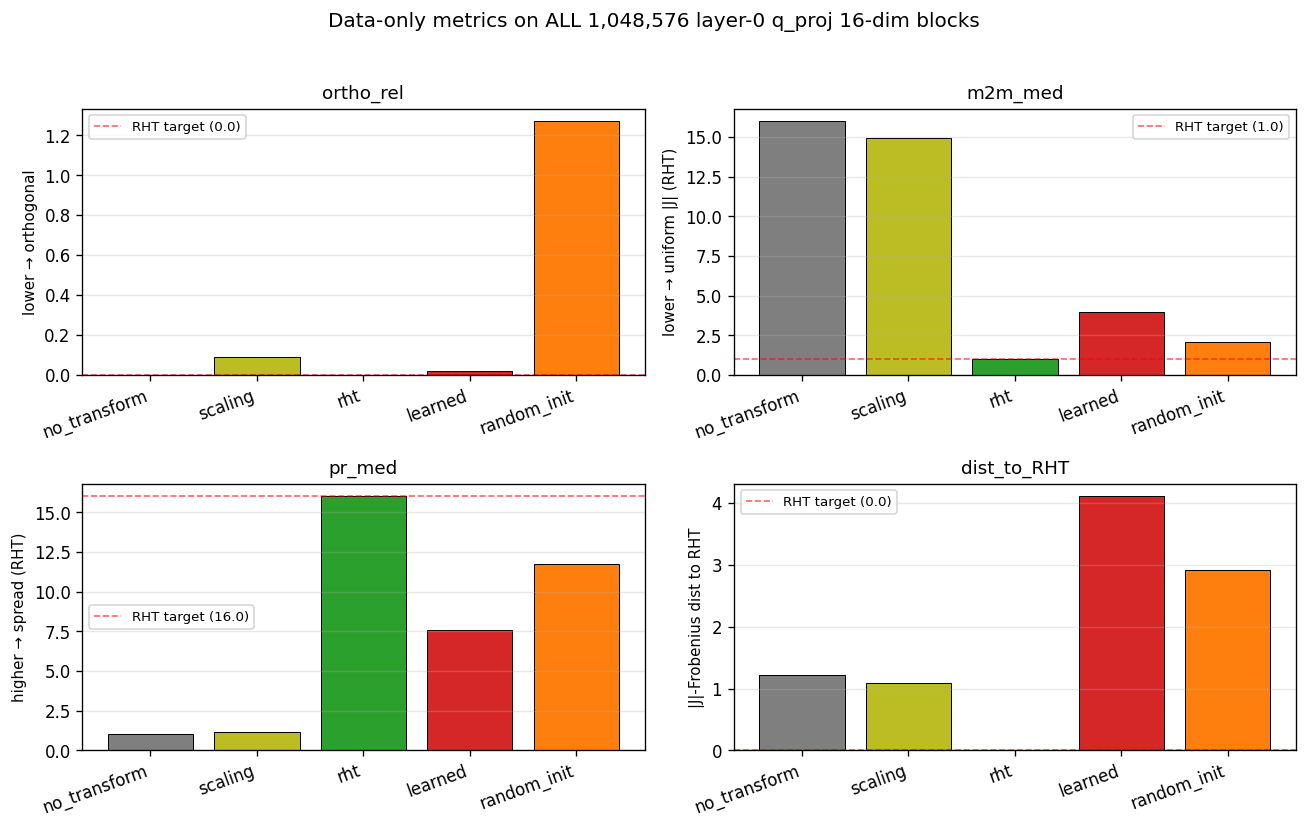

In [11]:
# Bar chart — 4 metrics in 2x2 grid, RHT-target line dashed red
color_map = {
    'no_transform': 'tab:gray', 'scaling': 'tab:olive', 'rht': 'tab:green',
    'learned': 'tab:red', 'random_init': 'tab:orange',
}
metric_specs = [
    ('ortho_rel',   'lower → orthogonal',           0.0),
    ('m2m_med',     'lower → uniform |J| (RHT)',    1.0),
    ('pr_med',      'higher → spread (RHT)',        16.0),
    ('dist_to_RHT', '|J|-Frobenius dist to RHT',    0.0),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 7), dpi=120)
xs = np.arange(len(names_order))
for ax, (metric, label, ref) in zip(axes.flatten(), metric_specs):
    vals = df[metric].values
    ax.bar(xs, vals,
           color=[color_map.get(t, 'C0') for t in names_order],
           edgecolor='black', linewidth=0.6)
    ax.axhline(ref, color='red', ls='--', alpha=0.6, linewidth=1.0,
               label=f'RHT target ({ref})')
    ax.set_xticks(xs); ax.set_xticklabels(names_order, rotation=20, ha='right')
    ax.set_title(metric, fontsize=11)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, axis='y', alpha=0.3); ax.legend(fontsize=8)
fig.suptitle(f'Data-only metrics on ALL {N:,} layer-0 q_proj 16-dim blocks', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'metrics_bar.png'); plt.show()


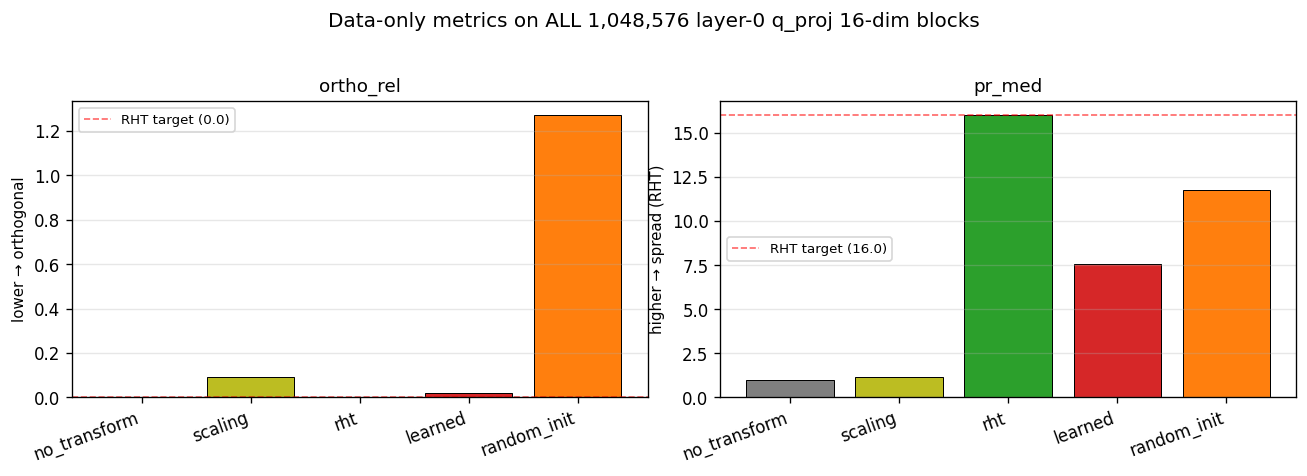

In [30]:
# Bar chart — 4 metrics in 2x2 grid, RHT-target line dashed red
color_map = {
    'no_transform': 'tab:gray', 'scaling': 'tab:olive', 'rht': 'tab:green',
    'learned': 'tab:red', 'random_init': 'tab:orange',
}
metric_specs = [
    ('ortho_rel',   'lower → orthogonal',           0.0),
    ('pr_med',      'higher → spread (RHT)',        16.0),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=120)
xs = np.arange(len(names_order))
for ax, (metric, label, ref) in zip(axes.flatten(), metric_specs):
    vals = df[metric].values
    ax.bar(xs, vals,
           color=[color_map.get(t, 'C0') for t in names_order],
           edgecolor='black', linewidth=0.6)
    ax.axhline(ref, color='red', ls='--', alpha=0.6, linewidth=1.0,
               label=f'RHT target ({ref})')
    ax.set_xticks(xs); ax.set_xticklabels(names_order, rotation=20, ha='right')
    ax.set_title(metric, fontsize=11)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, axis='y', alpha=0.3); ax.legend(fontsize=8)
fig.suptitle(f'Data-only metrics on ALL {N:,} layer-0 q_proj 16-dim blocks', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'metrics_bar.pdf'); plt.show()


## 8. Diagnostic — what does `scaling` (full-matrix per-column) look like in the OLS-Jacobian?

Per block $i$ (from column $c_i$ of $W$), the new scaling is $T(x_i) = x_i / \sigma_{c_i}$ —
**a block-specific scalar** $g_i = 1/\sigma_{c_i}$.  The within-block "Jacobian" at block $i$
is $g_i \cdot I$ (multiple of identity).

The **empirical (OLS) Jacobian** averages over the input distribution:
$$\hat J_\text{emp} = \Sigma_{zx}\Sigma_{xx}^{-1}.$$

If $g_i$ is *independent* of $x_i$ (within-block content uncorrelated with the column-std),
$$\Sigma_{zx} = \mathbb E\bigl[g_i\,(x_i-\bar x)(x_i-\bar x)^T\bigr] = \mathbb E[g_i]\,\Sigma_{xx},$$
so $\hat J_\text{emp} \approx \mathbb E[g_i]\,I$ — **a multiple of identity**, hence:
- ortho_rel ≈ 0
- m2m_med ≈ 16  (one-hot rows, like identity)
- pr_med ≈ 1   (one-hot cols)

So under empirical Jacobian, **scaling and identity look the same** in this metric set.
The scaling effect (per-block magnitude rescaling) is captured by $\Sigma_{zz}$
(variance reduction), not by $J^T J$ structure.

In [12]:
# Diagnostic for the new full-matrix scaling.
sigma_col_np = sigma_col.cpu().numpy()
g            = 1.0 / sigma_col_np                                              # per-column gain
print(f'σ_col  ({len(sigma_col_np)} columns)   min={sigma_col_np.min():.4f}  max={sigma_col_np.max():.4f}  '
      f'mean={sigma_col_np.mean():.4f}  std={sigma_col_np.std():.4f}')
print(f'gain g_i = 1/σ_col  mean E[g]={g.mean():.4f}   std={g.std():.4f}   '
      f'(predicted ‖J_emp‖_F ≈ E[g]·√d = {g.mean()*np.sqrt(BLOCK_DIM):.3f})')

# Inspect J_emp[scaling] — should be ≈ E[g]·I
J_sc = JACOBIANS_EMP['scaling']
diag_J = torch.diag(J_sc).numpy()
offmax = (J_sc - torch.diag(torch.diag(J_sc))).abs().max().item()
print(f'\nJ_emp[scaling]  diag mean={diag_J.mean():.4f}  std={diag_J.std():.4f}   '
      f'max |off-diag|={offmax:.4e}')
print(f'   ⇒ near-isotropic identity multiple (expected)')

# Variance reduction by scaling — captured in Cov(z), not J
var_x = X_ALL.var(dim=0).cpu().numpy()
var_z = Z_SCALED.var(dim=0).cpu().numpy()
print(f'\ninput-block variance:  per-dim mean={var_x.mean():.4f}  (raw block scale)')
print(f'scaled-block variance: per-dim mean={var_z.mean():.4f}  (after per-col norm)')
print(f'   variance ratio = {var_z.mean()/var_x.mean():.4f}  '
      f'(<1 ⇒ scaling reduces overall energy)')


σ_col  (4096 columns)   min=0.0071  max=4.5543  mean=0.7676  std=0.6409
gain g_i = 1/σ_col  mean E[g]=13.7832   std=25.0982   (predicted ‖J_emp‖_F ≈ E[g]·√d = 55.133)

J_emp[scaling]  diag mean=0.7716  std=0.0296   max |off-diag|=2.2567e-02
   ⇒ near-isotropic identity multiple (expected)

input-block variance:  per-dim mean=1.0000  (raw block scale)
scaled-block variance: per-dim mean=1.0000  (after per-col norm)
   variance ratio = 1.0000  (<1 ⇒ scaling reduces overall energy)


## 9. Per-scale comparison — does learned behave differently at different block scales?

Each 16-dim block comes from one column of $W$, with column-std $\sigma_c$.
Across columns, $\sigma_c$ ranges from $\sim 10^{-2}$ to $\sim 5$ (≈ 640× variation).

Question: do all transforms behave the same on low-σ blocks as on high-σ blocks?

**Method**: bin blocks by $\sigma_c$ (5 quantile bins).  Within each bin,
compute the empirical Jacobian $\hat J_\text{emp}^{(b)}$ from $(X_b, Z_b)$ pairs
restricted to that bin, then apply the 4 metrics.

If a transform is **scale-equivariant** (e.g., a linear $W$, or RHT), the metrics should
be **constant across bins** (within finite-sample noise).
If `learned` deviates from constancy, it means the encoder's effective linear behavior
**changes with input magnitude** — i.e., it is not purely linear and treats different
scales differently.

σ_per_block:  min=0.0071  max=4.5543  mean=0.7676  std=0.6409
  bin 0: σ ∈ [0.0071, 0.0527]   count=209920  (median σ=0.0168)
  bin 1: σ ∈ [0.0529, 0.6652]   count=209664  (median σ=0.1460)
  bin 2: σ ∈ [0.6652, 0.8821]   count=209664  (median σ=0.7798)
  bin 3: σ ∈ [0.8821, 1.4185]   count=209664  (median σ=1.0517)
  bin 4: σ ∈ [1.4188, 4.5543]   count=209664  (median σ=1.6110)


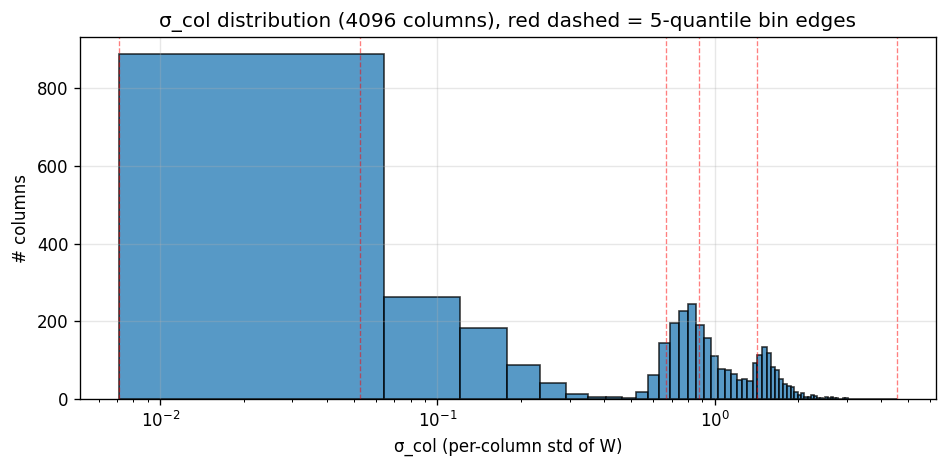

In [13]:
# 9a. Build per-block σ_c (each block's source column std), histogram, and quantile bins.
blocks_per_col = W_full.shape[0] // BLOCK_DIM            # 256
sigma_per_block = sigma_col.repeat_interleave(blocks_per_col)         # (N,)
print(f'σ_per_block:  min={float(sigma_per_block.min()):.4f}  max={float(sigma_per_block.max()):.4f}  '
      f'mean={float(sigma_per_block.mean()):.4f}  std={float(sigma_per_block.std()):.4f}')

# Quantile bin edges (5 bins)
N_BINS  = 5
spb_cpu = sigma_per_block.float().cpu()
qs      = torch.linspace(0, 1, N_BINS + 1)
edges   = torch.quantile(spb_cpu, qs).numpy()
boundaries = torch.tensor(edges[1:-1], dtype=sigma_per_block.dtype, device=sigma_per_block.device)
bin_idx = torch.bucketize(sigma_per_block, boundaries)   # (N,)
for b in range(N_BINS):
    mask = (bin_idx == b)
    s = sigma_per_block[mask]
    print(f'  bin {b}: σ ∈ [{float(s.min()):.4f}, {float(s.max()):.4f}]   '
          f'count={int(mask.sum())}  (median σ={float(s.median()):.4f})')

# Histogram of σ_c (over columns, log-scale) with bin edges
fig, ax = plt.subplots(1, 1, figsize=(8, 4), dpi=120)
ax.hist(sigma_col.cpu().numpy(), bins=80, color='tab:blue', alpha=0.75, edgecolor='black')
for e in edges:
    ax.axvline(e, color='red', ls='--', alpha=0.5, linewidth=0.8)
ax.set_xscale('log'); ax.set_xlabel('σ_col (per-column std of W)'); ax.set_ylabel('# columns')
ax.set_title('σ_col distribution (4096 columns), red dashed = 5-quantile bin edges')
ax.grid(True, alpha=0.3); fig.tight_layout()
fig.savefig(FIG_DIR / 'fig9a_sigma_col_hist.png'); plt.show()


In [14]:
# 9b. Per-bin × per-transform empirical Jacobian + 4 metrics.
@torch.no_grad()
def metrics_from_J(J, J_rht_ref):
    return {
        'ortho_rel':   orthogonality_metric(J),
        'm2m_med':     m2m_median(J),
        'pr_med':      pr_median(J),
        'dist_to_RHT': dist_to_rht(J, J_rht_ref),
    }

J_rht_global = JACOBIANS_EMP['rht']                                  # use global RHT as reference

per_bin_results = []
per_bin_J = {}
for b in range(N_BINS):
    mask = (bin_idx == b)
    X_b  = X_ALL[mask]
    sigma_b = sigma_per_block[mask]
    sigma_mid = float(sigma_b.median().cpu())
    for tname, tf in TRANSFORMS.items():
        if tname == 'scaling':
            Z_b = Z_SCALED[mask]                                     # use precomputed for full-matrix scaling
        else:
            Z_b = apply_transform_batched(tf, X_b)
        J = empirical_linear_jacobian(X_b, Z_b).detach().cpu()
        per_bin_J[(b, tname)] = J
        m = metrics_from_J(J, J_rht_global)
        per_bin_results.append({
            'bin': b, 'sigma_mid': sigma_mid, 'transform': tname, **m,
        })

df_bin = pd.DataFrame(per_bin_results)
df_bin.to_csv(FIG_DIR / 'fig9_per_scale_metrics.csv', index=False)
print(df_bin.to_string(index=False))


 bin  sigma_mid    transform    ortho_rel   m2m_med    pr_med  dist_to_RHT
   0   0.016761 no_transform 9.080033e-07 15.999983  1.000002 1.224744e+00
   0   0.016761      scaling 4.653280e-02 15.110677  1.120148 3.556506e+01
   0   0.016761          rht 1.249448e-06  1.000001 16.000000 1.988547e-06
   0   0.016761      learned 1.294694e-02  3.975089  7.523776 4.137612e+00
   0   0.016761  random_init 1.548977e+00  2.508457 11.115447 1.494790e+01
   1   0.145968 no_transform 1.351187e-07 16.000000  1.000000 1.224745e+00
   1   0.145968      scaling 6.722014e-02 14.598573  1.207975 2.434478e+00
   1   0.145968          rht 5.912864e-07  1.000001 16.000000 4.838576e-07
   1   0.145968      learned 1.342544e-02  3.980130  7.528701 4.133590e+00
   1   0.145968  random_init 1.388384e+00  2.468179 11.173975 5.481057e+00
   2   0.779774 no_transform 1.046442e-07 16.000000  1.000000 1.224745e+00
   2   0.779774      scaling 2.143094e-03 15.950527  1.005459 1.412195e+00
   2   0.779774          

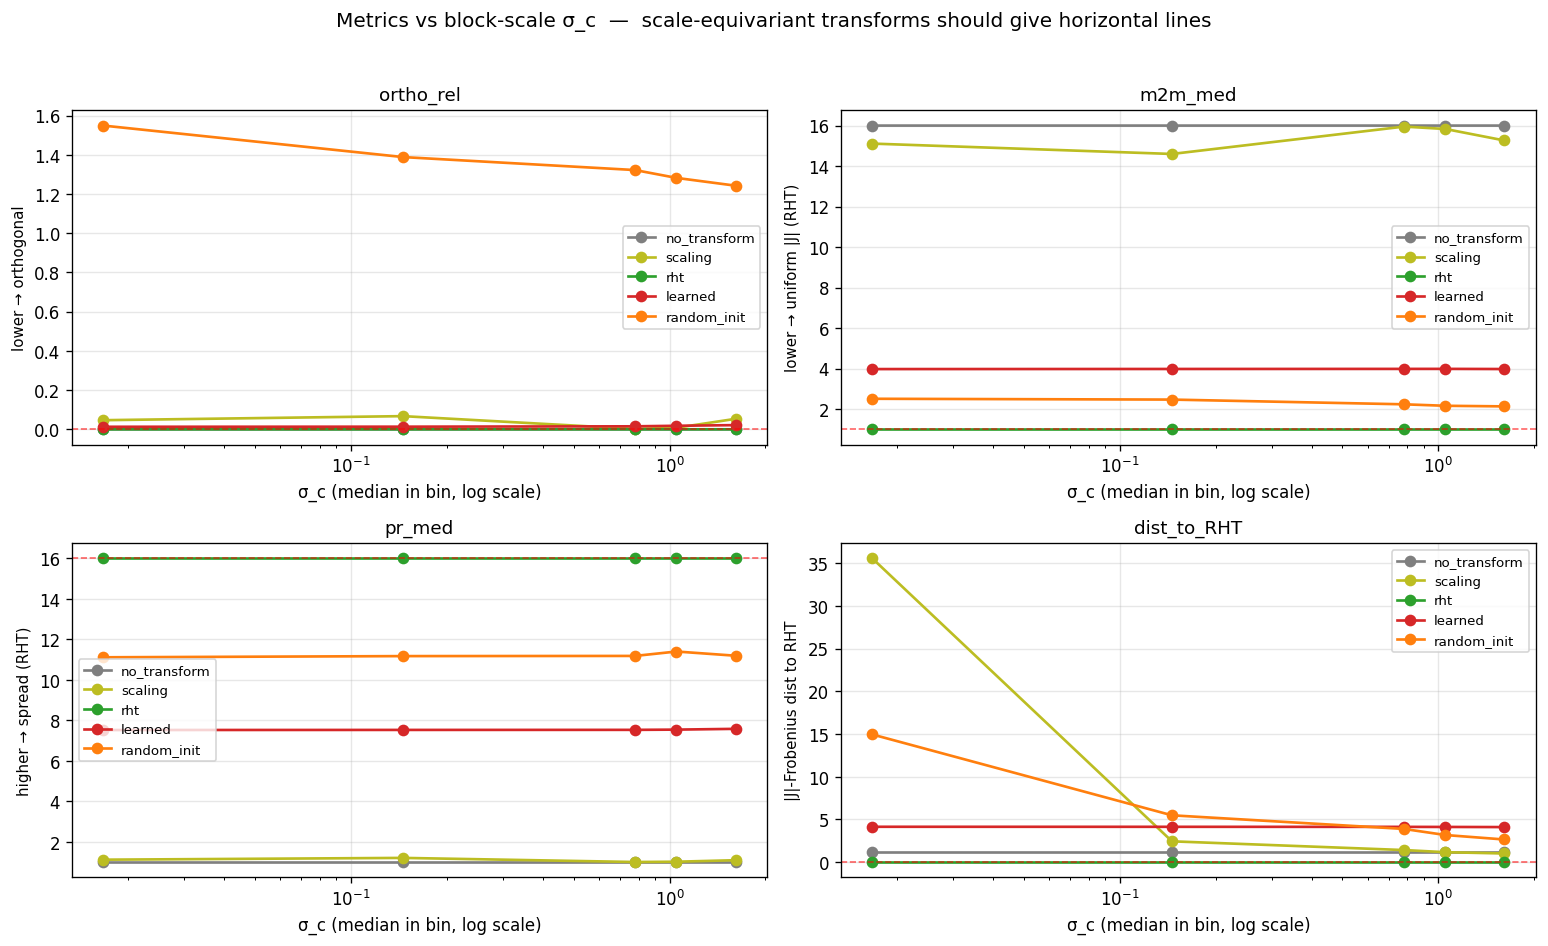

In [15]:
# 9c. Plot — 4 metrics vs σ_c bin, one line per transform.
metric_specs = [
    ('ortho_rel',   'lower → orthogonal',           0.0),
    ('m2m_med',     'lower → uniform |J| (RHT)',    1.0),
    ('pr_med',      'higher → spread (RHT)',        16.0),
    ('dist_to_RHT', '|J|-Frobenius dist to RHT',    0.0),
]
color_map = {
    'no_transform': 'tab:gray', 'scaling': 'tab:olive', 'rht': 'tab:green',
    'learned': 'tab:red', 'random_init': 'tab:orange',
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=120)
for ax, (metric, label, ref) in zip(axes.flatten(), metric_specs):
    for tname in names_order:
        sub = df_bin[df_bin['transform'] == tname].sort_values('bin')
        ax.plot(sub['sigma_mid'], sub[metric], marker='o', linewidth=1.6,
                color=color_map.get(tname, 'C0'), label=tname)
    ax.axhline(ref, color='red', ls='--', alpha=0.6, linewidth=1.0)
    ax.set_xscale('log')
    ax.set_xlabel('σ_c (median in bin, log scale)'); ax.set_ylabel(label, fontsize=9)
    ax.set_title(metric, fontsize=11)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
fig.suptitle('Metrics vs block-scale σ_c  —  scale-equivariant transforms should give horizontal lines',
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'fig9_per_scale_metrics.png'); plt.show()


## 10. Per-σ-bin spreading pattern — which channels do inputs go to?

For each σ-bin, look directly at the structure of $\hat J_\text{emp}$:
- **Heatmap of $|\hat J_\text{emp}|$** — full 16×16 mixing pattern.  Column $i$ shows
  where input dim $i$ goes; row $j$ shows which inputs feed channel $j$.
- **Column-wise sorted profile**: for each input dim $i$, sort $|\hat J_\text{emp}[:, i]|$
  descending; take the median across input dims.  This is the "typical spreading curve":
  rank-1 magnitude (the dominant channel each input goes to), rank-2, …, rank-16.
  - RHT reference: flat at $1/\sqrt{16} \approx 0.25$
  - identity reference: rank-1 = 1, rest = 0

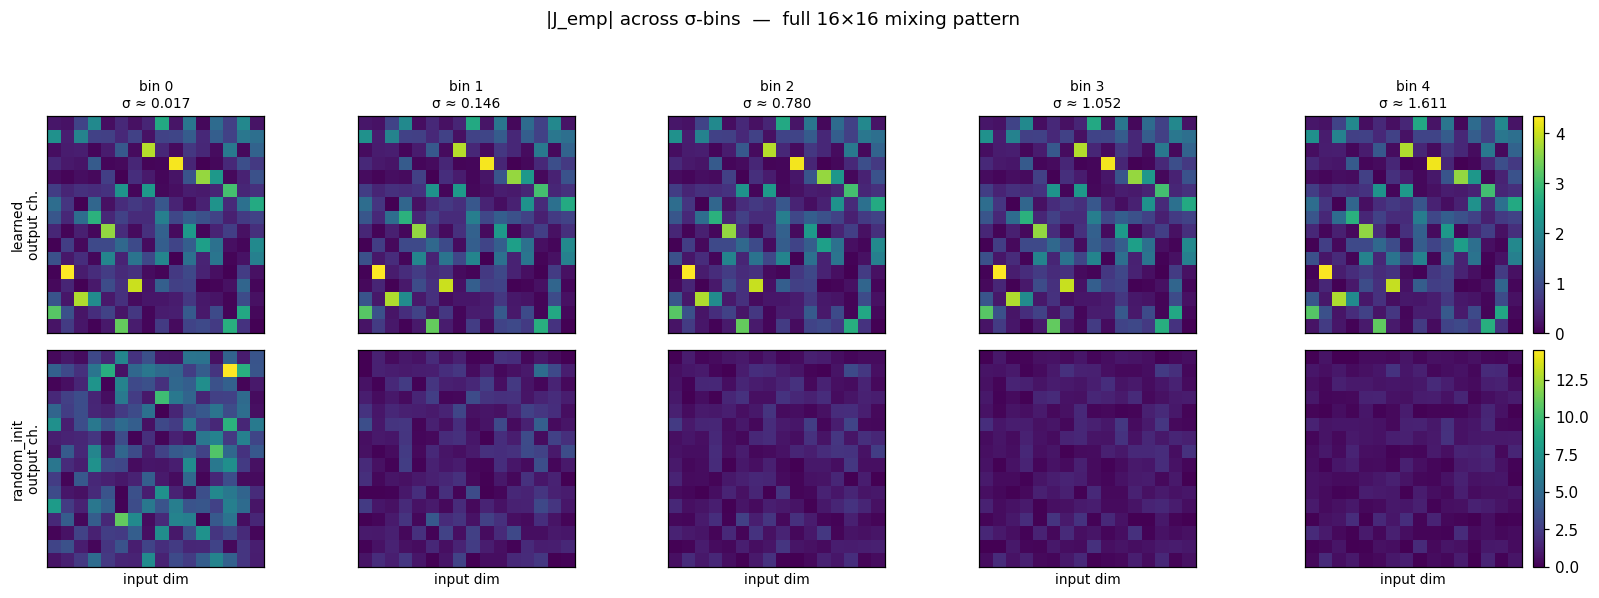

In [16]:
# 10a. |J_emp[learned]| heatmaps at each σ-bin (and random_init for contrast)
def _bin_label(b):
    s = sigma_per_block[bin_idx == b]
    return f'bin {b}\nσ ≈ {float(s.median()):.3f}'

fig, axes = plt.subplots(2, N_BINS, figsize=(3.0*N_BINS, 5.5), dpi=110)
for r, tname in enumerate(['learned', 'random_init']):
    # Common color scale per row to compare across bins
    Js  = [per_bin_J[(b, tname)].abs() for b in range(N_BINS)]
    vmax = max(float(J.max()) for J in Js)
    for b in range(N_BINS):
        ax = axes[r, b]
        im = ax.imshow(Js[b].numpy(), cmap='viridis', vmin=0, vmax=vmax)
        if r == 0: ax.set_title(_bin_label(b), fontsize=9)
        if b == 0: ax.set_ylabel(f'{tname}\noutput ch.', fontsize=9)
        if r == 1: ax.set_xlabel('input dim', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=axes[r, -1], fraction=0.046, pad=0.04)
fig.suptitle('|J_emp| across σ-bins  —  full 16×16 mixing pattern', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG_DIR / 'fig10a_per_bin_heatmaps.png'); plt.show()


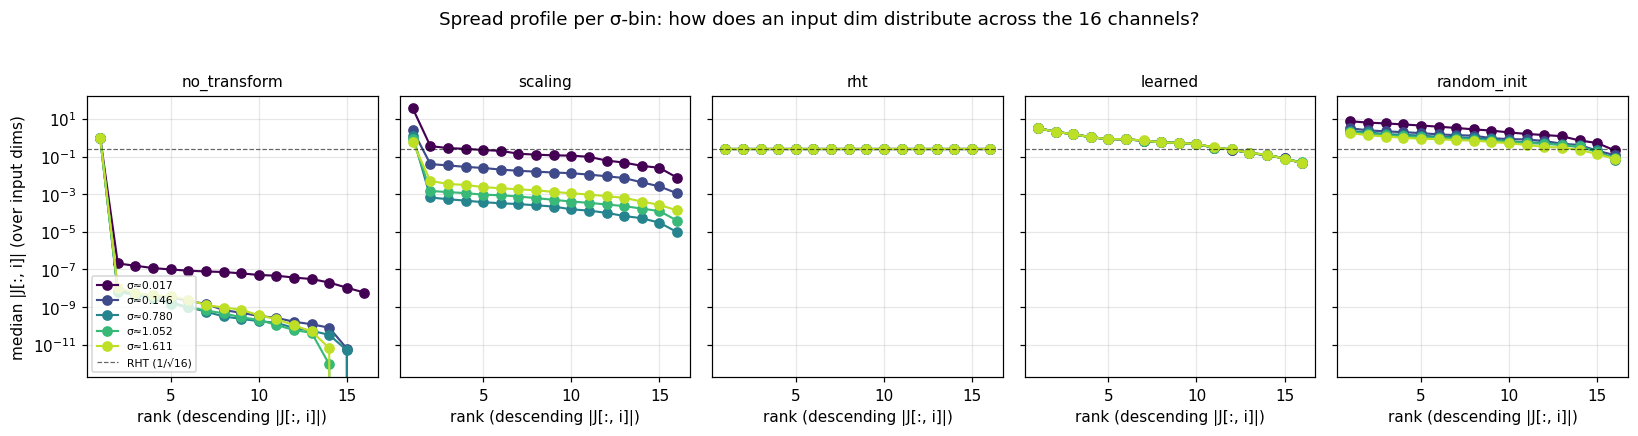

In [17]:
# 10b. Column-wise sorted "spread profile": for each input dim i, sort |J[:, i]| descending.
# Then take median across input dims.
fig, axes = plt.subplots(1, len(names_order), figsize=(3.0*len(names_order), 4), dpi=110, sharey=True)
ranks = np.arange(1, BLOCK_DIM + 1)
RHT_REF = 1.0 / math.sqrt(BLOCK_DIM)

# Color one curve per bin
import matplotlib.cm as cm
bin_colors = cm.viridis(np.linspace(0.0, 0.9, N_BINS))

for c, tname in enumerate(names_order):
    ax = axes[c]
    for b in range(N_BINS):
        J = per_bin_J[(b, tname)].abs().numpy()                      # (16, 16)
        sorted_cols = np.sort(J, axis=0)[::-1]                       # (rank, input_dim)
        median_profile = np.median(sorted_cols, axis=1)              # (16,)
        s_mid = float(sigma_per_block[bin_idx == b].median())
        ax.plot(ranks, median_profile, marker='o', linewidth=1.4,
                color=bin_colors[b], label=f'σ≈{s_mid:.3f}')
    # references
    ax.axhline(RHT_REF, color='black', ls='--', alpha=0.6, linewidth=0.8,
               label=f'RHT (1/√{BLOCK_DIM})' if c == 0 else None)
    ax.set_yscale('log')
    ax.set_xlabel('rank (descending |J[:, i]|)')
    if c == 0: ax.set_ylabel('median |J[:, i]| (over input dims)')
    ax.set_title(tname, fontsize=10)
    ax.grid(True, which='both', alpha=0.3)
    if c == 0: ax.legend(fontsize=7, loc='lower left')
fig.suptitle('Spread profile per σ-bin: how does an input dim distribute across the 16 channels?', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG_DIR / 'fig10b_spread_profiles.png'); plt.show()


## 11. PR (participation ratio) distribution per σ-bin

For each transform, plot the histogram of `pr_per_col_i` across the 16 input dims, **stratified by column scale σ_c bin**.
This is the σ-conditional version of the energy-mixing histogram (high PR ⇒ Hadamard-like).

If a transform is scale-equivariant (linear / RHT), the histograms across σ-bins should overlap.
The `learned` encoder may show a σ-dependent shift if it adapts to input magnitude.

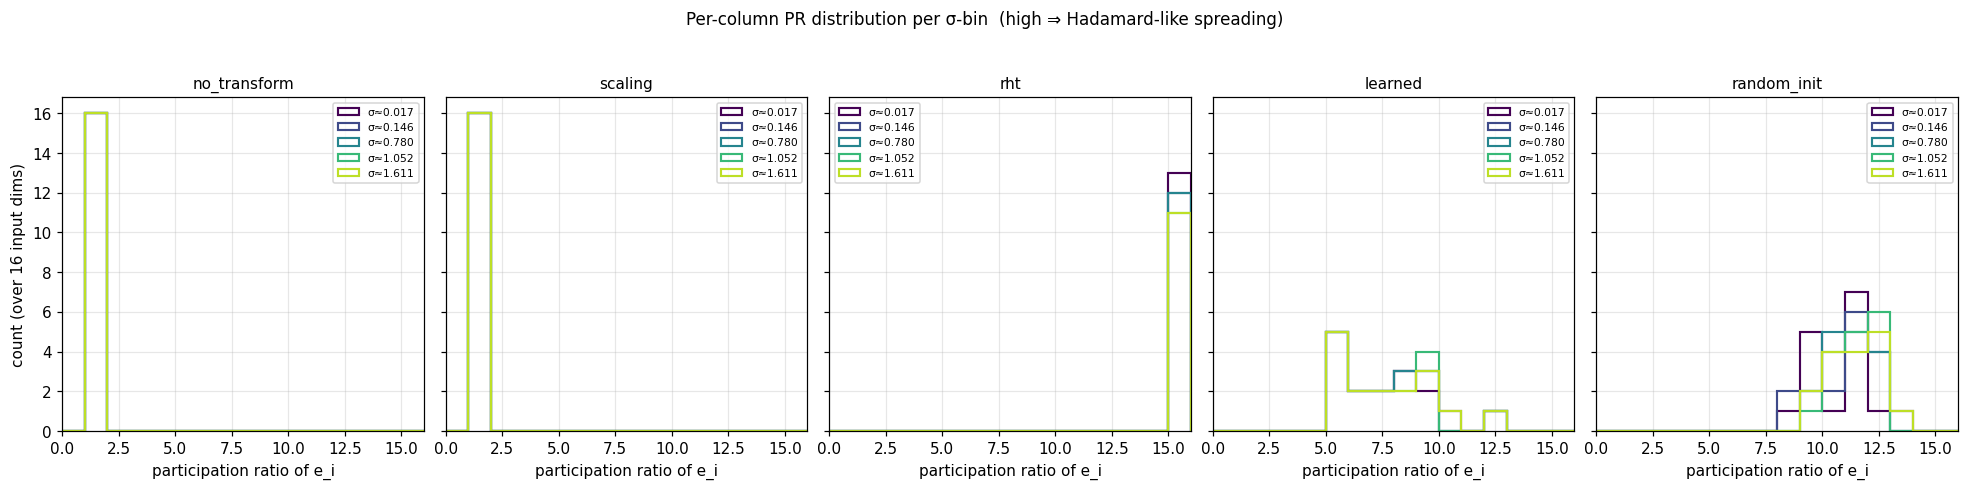

In [18]:
import matplotlib.cm as cm

@torch.no_grad()
def pr_per_col(J):
    A = J.abs()
    col_sum  = A.sum(dim=0)
    col_l2sq = (A ** 2).sum(dim=0).clamp_min(1e-12)
    return ((col_sum ** 2) / col_l2sq).cpu().numpy()        # (16,)

bin_colors = cm.viridis(np.linspace(0.0, 0.9, N_BINS))
PR_BINS = np.linspace(0, BLOCK_DIM, 17)                     # PR ∈ [0, 16]

fig, axes = plt.subplots(1, len(names_order), figsize=(3.6*len(names_order), 4.5), dpi=110, sharey=True)
for c, tname in enumerate(names_order):
    ax = axes[c]
    for b in range(N_BINS):
        pr_vals = pr_per_col(per_bin_J[(b, tname)])
        s_mid   = float(sigma_per_block[bin_idx == b].median())
        ax.hist(pr_vals, bins=PR_BINS, histtype='step', linewidth=1.4,
                color=bin_colors[b], label=f'σ≈{s_mid:.3f}')
    ax.set_xlabel('participation ratio of e_i')
    if c == 0: ax.set_ylabel('count (over 16 input dims)')
    ax.set_title(tname, fontsize=10)
    ax.set_xlim(0, BLOCK_DIM)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
fig.suptitle('Per-column PR distribution per σ-bin  (high ⇒ Hadamard-like spreading)',
             fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG_DIR / 'fig11_pr_per_sigma_bin.png'); plt.show()

## 12. Q_LEVEL comparison — does the learned encoder behave differently per quality level?

The learned `nwc_ql` encoder takes a `q_level ∈ {0, 1, …, Q-1}` (here Q=4) as conditioning input.
Recompute J_emp + 4 metrics + per-column PR distribution for every Q level, both globally and per σ-bin.

Hypothesis:
- Higher Q ⇒ more bits/sample ⇒ encoder may afford higher-fidelity (less aggressive) transform.
- Lower Q ⇒ fewer bits ⇒ encoder may push toward more compressible (e.g., more "RHT-like") latent.

In [19]:
# 12a. Sweep Q_LEVEL ∈ {0, 1, ..., Q-1}.  For each Q level, compute J_emp globally
# and per σ-bin, then collect 4 metrics and per-column PR distribution.

Q_LEVELS = list(range(int(nwc.Q)))
print(f'Sweeping Q_LEVEL ∈ {Q_LEVELS}')

qb_J        = {}      # (q, bin_or_'all') -> J_emp (16,16) on cpu
qb_metrics  = []      # rows for DataFrame

for q in Q_LEVELS:
    tf_q = make_learned_transform(nwc, q_level=q)
    Z_q  = apply_transform_batched(tf_q, X_ALL)
    # global
    J_g  = empirical_linear_jacobian(X_ALL, Z_q).detach().cpu()
    qb_J[(q, 'all')] = J_g
    qb_metrics.append({'Q_LEVEL': q, 'bin': 'all', 'sigma_mid': float('nan'),
                       **metrics_from_J(J_g, J_rht_global)})
    # per σ-bin
    for b in range(N_BINS):
        mask = (bin_idx == b)
        J_b  = empirical_linear_jacobian(X_ALL[mask], Z_q[mask]).detach().cpu()
        qb_J[(q, b)] = J_b
        s_mid = float(sigma_per_block[mask].median())
        qb_metrics.append({'Q_LEVEL': q, 'bin': b, 'sigma_mid': s_mid,
                           **metrics_from_J(J_b, J_rht_global)})
    del Z_q
    torch.cuda.empty_cache()

df_q = pd.DataFrame(qb_metrics)
df_q.to_csv(FIG_DIR / 'fig12_qlevel_metrics.csv', index=False)
print('\nGlobal (all bins) metrics by Q_LEVEL:')
print(df_q[df_q['bin'] == 'all'].drop(columns=['bin', 'sigma_mid']).to_string(index=False))

Sweeping Q_LEVEL ∈ [0, 1, 2, 3]

Global (all bins) metrics by Q_LEVEL:
 Q_LEVEL  ortho_rel  m2m_med   pr_med  dist_to_RHT
       0   0.016784 9.255960 2.945773     3.115327
       1   0.019376 3.979862 7.564452     4.110147
       2   0.099260 2.501355 9.809113     9.716044
       3   0.135477 2.486771 9.707855    11.746546


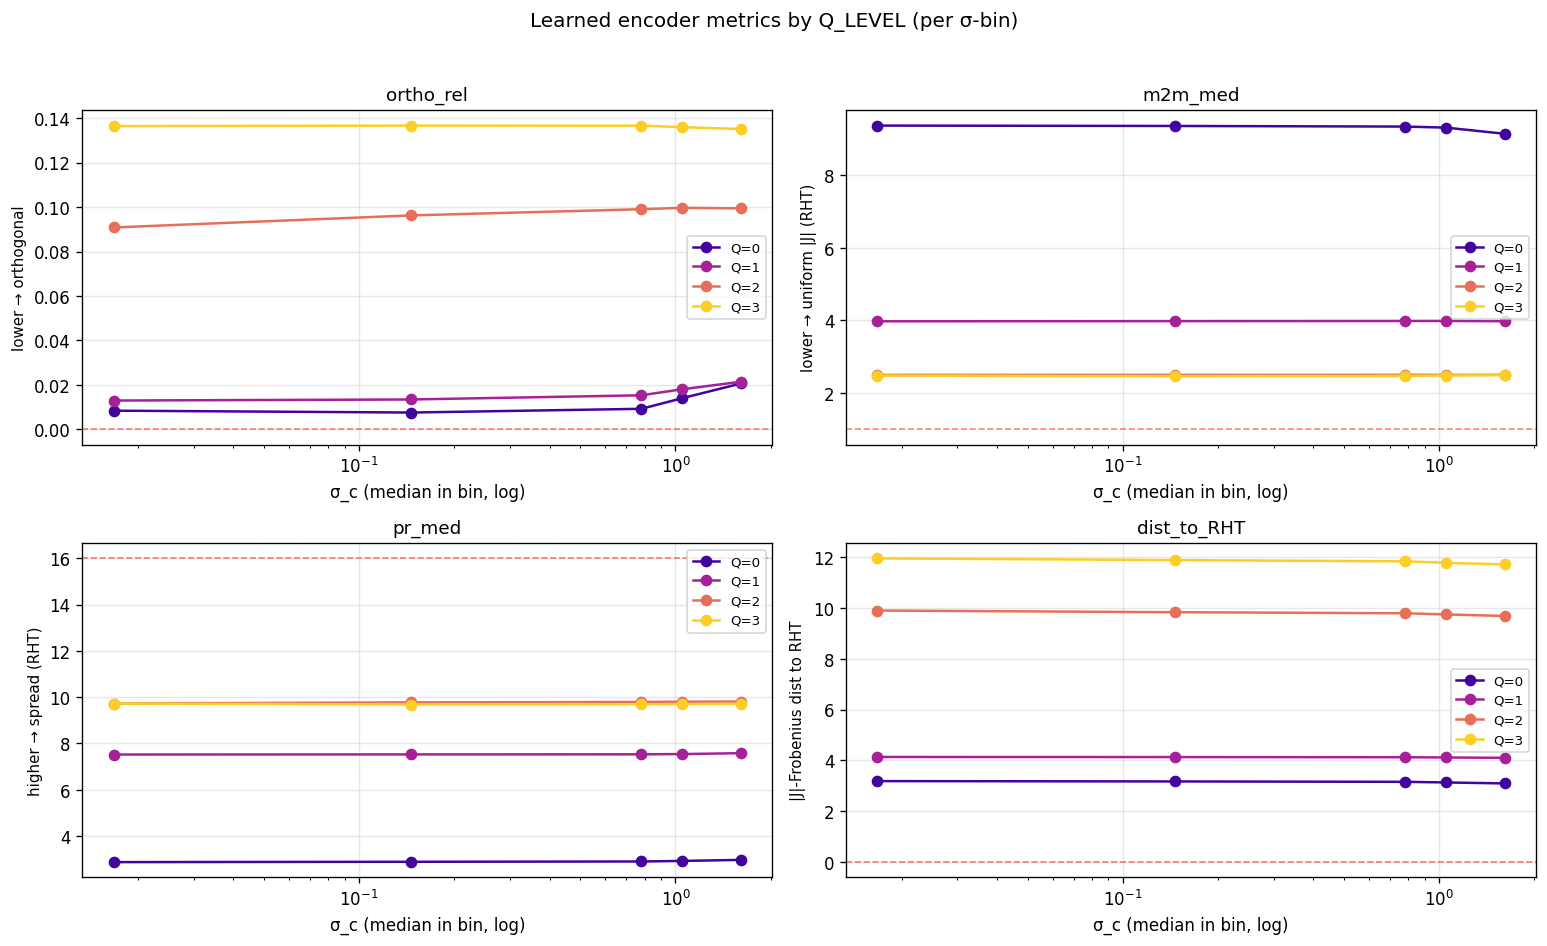

In [20]:
# 12b. Plot — 4 metrics vs σ-bin, one line per Q_LEVEL.
q_colors = cm.plasma(np.linspace(0.1, 0.9, len(Q_LEVELS)))

fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=120)
for ax, (metric, label, ref) in zip(axes.flatten(), metric_specs):
    for qi, q in enumerate(Q_LEVELS):
        sub = df_q[(df_q['Q_LEVEL'] == q) & (df_q['bin'] != 'all')].sort_values('sigma_mid')
        ax.plot(sub['sigma_mid'], sub[metric], marker='o', linewidth=1.5,
                color=q_colors[qi], label=f'Q={q}')
    ax.axhline(ref, color='red', ls='--', alpha=0.5, linewidth=1.0)
    ax.set_xscale('log')
    ax.set_xlabel('σ_c (median in bin, log)'); ax.set_ylabel(label, fontsize=9)
    ax.set_title(metric, fontsize=11)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
fig.suptitle('Learned encoder metrics by Q_LEVEL (per σ-bin)', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'fig12b_qlevel_metrics_per_sigma.png'); plt.show()

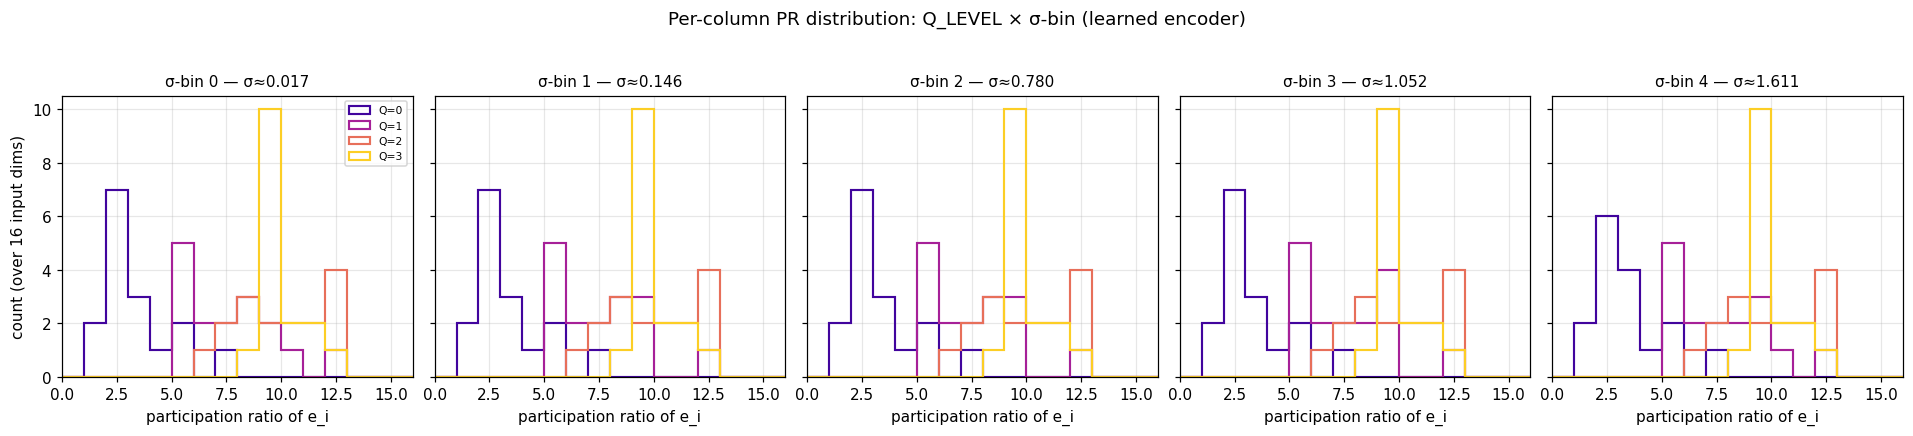

In [21]:
# 12c. PR histograms — N_BINS panels (one per σ-bin), Q_LEVEL curves overlaid in each.
fig, axes = plt.subplots(1, N_BINS, figsize=(3.5*N_BINS, 4), dpi=110, sharey=True)
for b in range(N_BINS):
    ax = axes[b]
    for qi, q in enumerate(Q_LEVELS):
        pr_vals = pr_per_col(qb_J[(q, b)])
        ax.hist(pr_vals, bins=PR_BINS, histtype='step', linewidth=1.4,
                color=q_colors[qi], label=f'Q={q}')
    s_mid = float(sigma_per_block[bin_idx == b].median())
    ax.set_xlabel('participation ratio of e_i')
    if b == 0: ax.set_ylabel('count (over 16 input dims)')
    ax.set_title(f'σ-bin {b} — σ≈{s_mid:.3f}', fontsize=10)
    ax.set_xlim(0, BLOCK_DIM); ax.grid(True, alpha=0.3)
    if b == 0: ax.legend(fontsize=7)
fig.suptitle('Per-column PR distribution: Q_LEVEL × σ-bin (learned encoder)', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG_DIR / 'fig12c_qlevel_pr_per_sigma.png'); plt.show()

## 13. Per-sample local Jacobian — metric distribution

Switch from the **single empirical linear Jacobian** (`Σ_zx Σ_xx⁻¹`, one 16×16 per transform)
to the **per-sample local Jacobian** $J(x_n) = \partial T(x)/\partial x \big|_{x = x_n}$ via
`torch.autograd.functional.jacobian`.  Then compute the 4 metrics per sample → distribution
over samples (mean ± std + histograms).

For **linear** transforms (identity, scaling, rht): J(x) is constant — all samples give the
same metrics (zero variance).
For **nonlinear** transforms (learned NWC encoder, random_init): J(x) varies → metric
distribution has nontrivial spread, revealing the encoder's heterogeneity.

We subsample `N_SUB` blocks (typically 2048) and run autograd per sample.

In [22]:
# 13a. Per-sample local Jacobian via torch.autograd.functional.jacobian.
# Generic helper that follows the (R^d → R^d) signature; we wrap each transform
# to accept a single sample (d,) and return a single sample (d,).

def compute_local_jacobian(T, x):
    """T: R^d → R^d.  x: (d,).  Returns J of shape (d, d)."""
    x = x.detach().requires_grad_(True)
    def func(x):
        return T(x)
    return torch.autograd.functional.jacobian(func, x)

def to_single_sample(T):
    """Wrap a (B, d) → (B, d) transform so it accepts (d,) and returns (d,)."""
    def f(x):
        return T(x.unsqueeze(0)).squeeze(0)
    return f

# Vectorized per-sample metric computation given a batch of Jacobians.
@torch.no_grad()
def metrics_array_for_J(J_batch, J_rht_ref):
    """J_batch: (B, D, D).  J_rht_ref: (D, D).  Returns (B, 4) tensor of
    [ortho_rel, m2m_med, pr_med, dist_to_RHT] per sample."""
    B, D, _ = J_batch.shape
    eye = torch.eye(D, device=J_batch.device, dtype=J_batch.dtype).unsqueeze(0)
    # ortho_rel
    G = J_batch.transpose(-1, -2) @ J_batch                              # (B, D, D)
    alpha = G.diagonal(dim1=-2, dim2=-1).sum(dim=-1) / D                 # (B,)
    diff = G - alpha.view(B, 1, 1) * eye                                 # (B, D, D)
    norm_diff = torch.linalg.norm(diff.reshape(B, -1), dim=-1)
    norm_alphaI = alpha.abs() * math.sqrt(D)
    ortho_rel = norm_diff / norm_alphaI.clamp_min(1e-12)
    # m2m_med (row-wise)
    A = J_batch.abs()
    row_max  = A.max(dim=-1).values                                      # (B, D)
    row_mean = A.mean(dim=-1).clamp_min(1e-12)
    m2m_med  = (row_max / row_mean).median(dim=-1).values                # (B,)
    # pr_med (col-wise)
    col_sum  = A.sum(dim=-2)                                             # (B, D)
    col_l2sq = (A ** 2).sum(dim=-2).clamp_min(1e-12)
    pr_med   = ((col_sum ** 2) / col_l2sq).median(dim=-1).values         # (B,)
    # dist_to_RHT
    rht_norm = torch.linalg.norm(J_rht_ref).clamp_min(1e-12)
    dist     = torch.linalg.norm(
                  (A - J_rht_ref.abs().unsqueeze(0)).reshape(B, -1), dim=-1) / rht_norm
    return torch.stack([ortho_rel, m2m_med, pr_med, dist], dim=-1)       # (B, 4)

print('Helpers ready: compute_local_jacobian, to_single_sample, metrics_array_for_J')

Helpers ready: compute_local_jacobian, to_single_sample, metrics_array_for_J


In [23]:
# 13b. Subsample N_SUB blocks → per-sample local J + metrics for each transform.
# For analytically-known linear transforms (no_transform, scaling) we skip autograd.

N_SUB = 2048
torch.manual_seed(0)
sub_idx = torch.randperm(N, device=DEVICE)[:N_SUB]
X_sub   = X_ALL[sub_idx]                                                # (N_SUB, 16)
sigma_sub = sigma_per_block.to(DEVICE)[sub_idx]                         # (N_SUB,)

J_rht_ref = JACOBIANS_EMP['rht'].to(DEVICE)                             # global RHT reference

per_sample_metrics = {}                                                 # tname -> (N_SUB, 4) ndarray
per_sample_J       = {}                                                 # tname -> (N_SUB, 16, 16) on cpu (optional)

eye_d = torch.eye(BLOCK_DIM, device=DEVICE)

for tname, tf in TRANSFORMS.items():
    if tname == 'no_transform':
        # J(x) = I (constant)
        J_batch = eye_d.unsqueeze(0).expand(N_SUB, -1, -1).contiguous()
    elif tname == 'scaling':
        # Block-specific scalar: J(x_n) = g_n · I,  g_n = 1/σ_{c(n)}
        g_n = (1.0 / sigma_sub).to(DEVICE)
        J_batch = g_n.view(-1, 1, 1) * eye_d.unsqueeze(0)               # (N_SUB, 16, 16)
    else:
        # Use autograd per-sample (rht is linear so all J_n equal — we still compute via autograd
        # for uniform code, the per-sample variance will collapse to ~0).
        f_single = to_single_sample(tf)
        J_list = []
        for i in range(N_SUB):
            J_n = compute_local_jacobian(f_single, X_sub[i])
            J_list.append(J_n.detach())
        J_batch = torch.stack(J_list, 0)                                # (N_SUB, 16, 16)

    metrics = metrics_array_for_J(J_batch, J_rht_ref)                   # (N_SUB, 4)
    per_sample_metrics[tname] = metrics.cpu().numpy()
    per_sample_J[tname]       = J_batch.cpu()
    m_mean = metrics.mean(0).cpu().numpy()
    m_std  = metrics.std(0).cpu().numpy()
    print(f'{tname:14s}  ortho={m_mean[0]:.4f}±{m_std[0]:.4f}  '
          f'm2m={m_mean[1]:.4f}±{m_std[1]:.4f}  '
          f'pr={m_mean[2]:.4f}±{m_std[2]:.4f}  '
          f'dist={m_mean[3]:.4f}±{m_std[3]:.4f}')

# Save mean ± std summary
rows = []
for tname in names_order:
    m = per_sample_metrics[tname]
    rows.append({
        'transform':         tname,
        'ortho_rel_mean':    float(m[:, 0].mean()),  'ortho_rel_std':   float(m[:, 0].std()),
        'm2m_med_mean':      float(m[:, 1].mean()),  'm2m_med_std':     float(m[:, 1].std()),
        'pr_med_mean':       float(m[:, 2].mean()),  'pr_med_std':      float(m[:, 2].std()),
        'dist_to_RHT_mean':  float(m[:, 3].mean()),  'dist_to_RHT_std': float(m[:, 3].std()),
    })
df_ps = pd.DataFrame(rows)
df_ps.to_csv(FIG_DIR / 'fig13_per_sample_metrics.csv', index=False)
print('\nSaved → fig13_per_sample_metrics.csv')
print(df_ps.round(4).to_string(index=False))

no_transform    ortho=0.0000±0.0000  m2m=16.0000±0.0000  pr=1.0000±0.0000  dist=1.2247±0.0000
scaling         ortho=0.0000±0.0000  m2m=16.0000±0.0000  pr=1.0000±0.0000  dist=13.4945±24.6128
rht             ortho=0.0000±0.0000  m2m=1.0000±0.0000  pr=16.0000±0.0000  dist=0.0000±0.0000
learned         ortho=0.0190±0.0138  m2m=3.9789±0.0190  pr=7.5348±0.0495  dist=4.1302±0.0162
random_init     ortho=1.5095±0.1475  m2m=2.4696±0.1278  pr=10.7254±0.3525  dist=9.0343±5.1852

Saved → fig13_per_sample_metrics.csv
   transform  ortho_rel_mean  ortho_rel_std  m2m_med_mean  m2m_med_std  pr_med_mean  pr_med_std  dist_to_RHT_mean  dist_to_RHT_std
no_transform          0.0000         0.0000       16.0000       0.0000       1.0000      0.0000            1.2247           0.0000
     scaling          0.0000         0.0000       16.0000       0.0000       1.0000      0.0000           13.4945          24.6068
         rht          0.0000         0.0000        1.0000       0.0000      16.0000      0.0000   

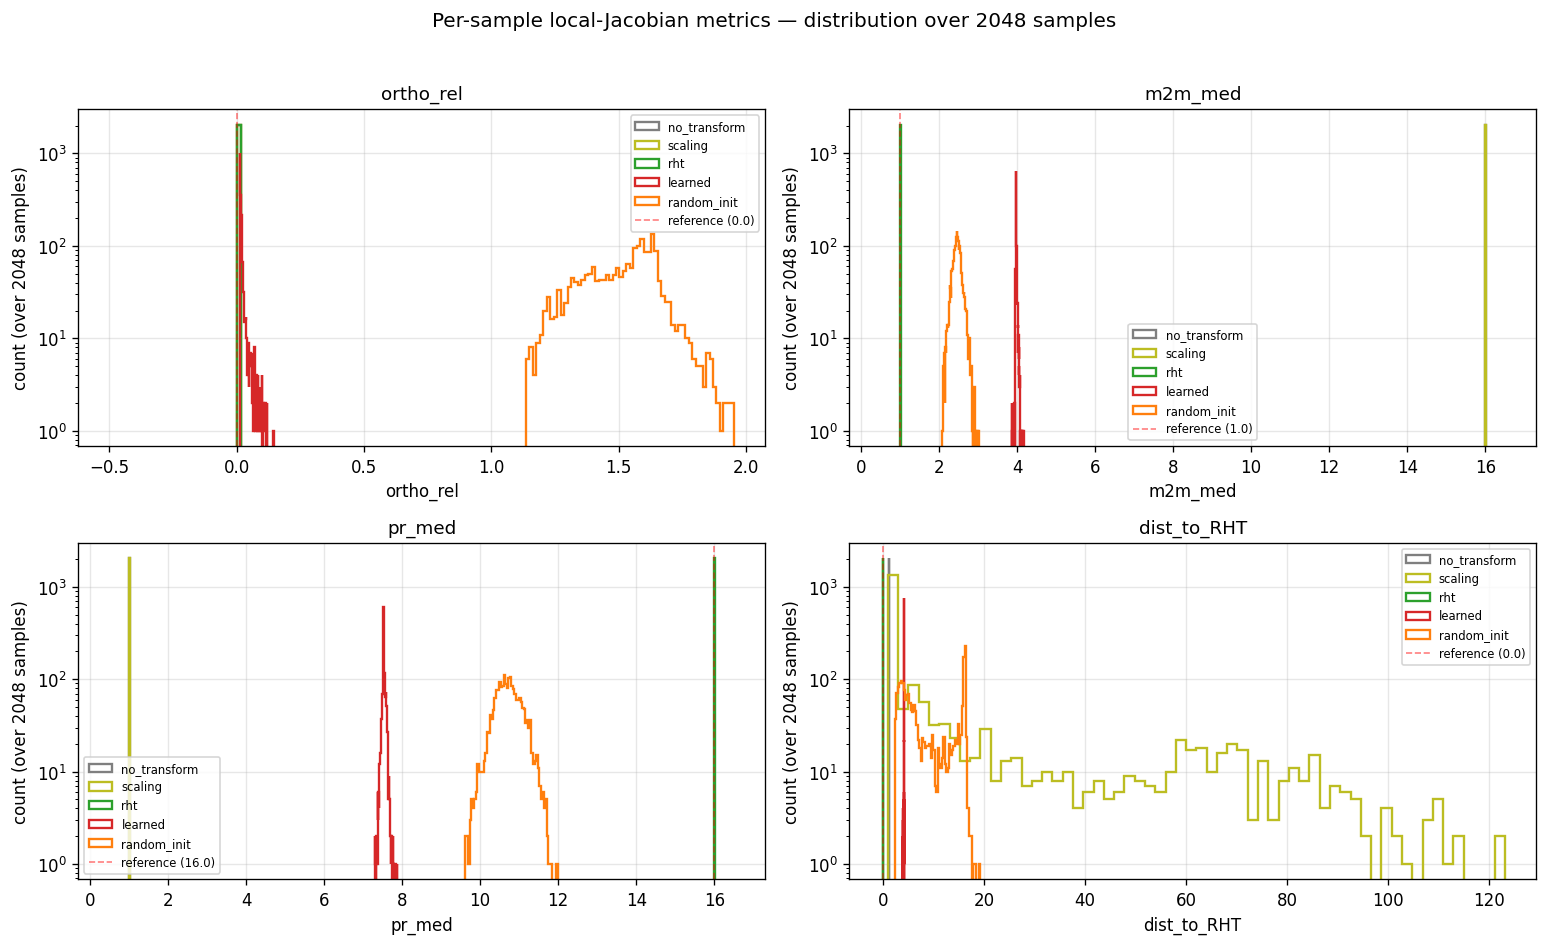

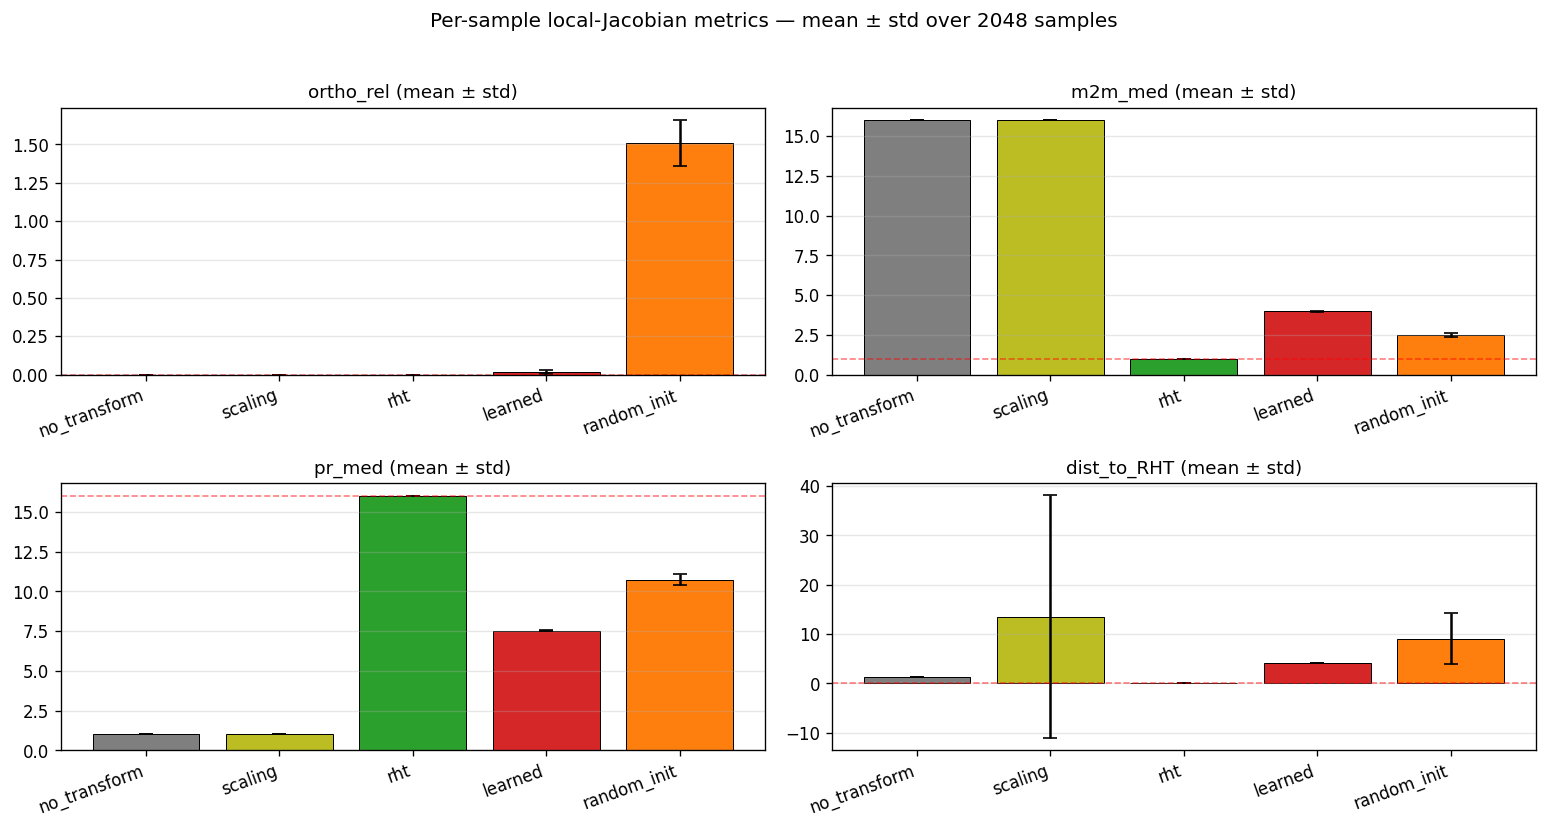

In [24]:
# 13c. Plot — per-sample metric distributions (histogram, log-y) + mean±std bar chart.
metric_cols = ['ortho_rel', 'm2m_med', 'pr_med', 'dist_to_RHT']
metric_refs = [0.0, 1.0, 16.0, 0.0]

# Histograms (4 panels, transforms overlaid)
fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=120)
for idx, (ax, mname, ref) in enumerate(zip(axes.flatten(), metric_cols, metric_refs)):
    for tname in names_order:
        vals = per_sample_metrics[tname][:, idx]
        ax.hist(vals, bins=60, histtype='step', linewidth=1.4,
                color=color_map.get(tname, 'C0'), label=tname)
    ax.axvline(ref, color='red', ls='--', alpha=0.5, linewidth=1.0,
               label=f'reference ({ref})')
    ax.set_xlabel(mname)
    ax.set_ylabel(f'count (over {N_SUB} samples)')
    ax.set_title(mname, fontsize=11)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
fig.suptitle(f'Per-sample local-Jacobian metrics — distribution over {N_SUB} samples',
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'fig13a_per_sample_hist.png'); plt.show()

# Bar chart with mean ± std error bars
fig, axes = plt.subplots(2, 2, figsize=(13, 7), dpi=120)
xs = np.arange(len(names_order))
for ax, mname, ref in zip(axes.flatten(), metric_cols, metric_refs):
    means = df_ps[f'{mname}_mean'].values
    stds  = df_ps[f'{mname}_std'].values
    ax.bar(xs, means, yerr=stds, capsize=4,
           color=[color_map.get(t, 'C0') for t in names_order],
           edgecolor='black', linewidth=0.6)
    ax.axhline(ref, color='red', ls='--', alpha=0.5, linewidth=1.0)
    ax.set_xticks(xs); ax.set_xticklabels(names_order, rotation=20, ha='right')
    ax.set_title(f'{mname} (mean ± std)', fontsize=11)
    ax.grid(True, axis='y', alpha=0.3)
fig.suptitle(f'Per-sample local-Jacobian metrics — mean ± std over {N_SUB} samples',
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'fig13b_per_sample_meanstd.png'); plt.show()

## 14. Per-sample metrics × σ-bin

Stratify the N_SUB per-sample local-Jacobian metrics from §13 by σ-bin.
- §14a/b: 4 metrics, mean ± std per σ-bin, one line per transform.
- §14c: per-sample `pr_med` histogram per σ-bin × transform.

In [25]:
# 14a. Bin per-sample metrics by σ-bin.
bin_idx_sub = bin_idx[sub_idx.to(bin_idx.device)].cpu().numpy()              # (N_SUB,)

rows = []
for tname in names_order:
    m = per_sample_metrics[tname]                                            # (N_SUB, 4)
    for b in range(N_BINS):
        mask = bin_idx_sub == b
        if not mask.any():
            continue
        s_mid = float(sigma_per_block[bin_idx == b].median())
        rows.append({
            'transform': tname, 'bin': b, 'sigma_mid': s_mid, 'n': int(mask.sum()),
            'ortho_rel_mean':   float(m[mask, 0].mean()), 'ortho_rel_std':   float(m[mask, 0].std()),
            'm2m_med_mean':     float(m[mask, 1].mean()), 'm2m_med_std':     float(m[mask, 1].std()),
            'pr_med_mean':      float(m[mask, 2].mean()), 'pr_med_std':      float(m[mask, 2].std()),
            'dist_to_RHT_mean': float(m[mask, 3].mean()), 'dist_to_RHT_std': float(m[mask, 3].std()),
        })
df_psbin = pd.DataFrame(rows)
df_psbin.to_csv(FIG_DIR / 'fig14_per_sample_per_sigma.csv', index=False)
print(df_psbin.round(4).to_string(index=False))

   transform  bin  sigma_mid   n  ortho_rel_mean  ortho_rel_std  m2m_med_mean  m2m_med_std  pr_med_mean  pr_med_std  dist_to_RHT_mean  dist_to_RHT_std
no_transform    0     0.0168 401          0.0000         0.0000       16.0000       0.0000       1.0000      0.0000            1.2247           0.0000
no_transform    1     0.1460 392          0.0000         0.0000       16.0000       0.0000       1.0000      0.0000            1.2247           0.0000
no_transform    2     0.7798 412          0.0000         0.0000       16.0000       0.0000       1.0000      0.0000            1.2247           0.0000
no_transform    3     1.0517 430          0.0000         0.0000       16.0000       0.0000       1.0000      0.0000            1.2247           0.0000
no_transform    4     1.6110 413          0.0000         0.0000       16.0000       0.0000       1.0000      0.0000            1.2247           0.0000
     scaling    0     0.0168 401          0.0000         0.0000       16.0000       0.0000    

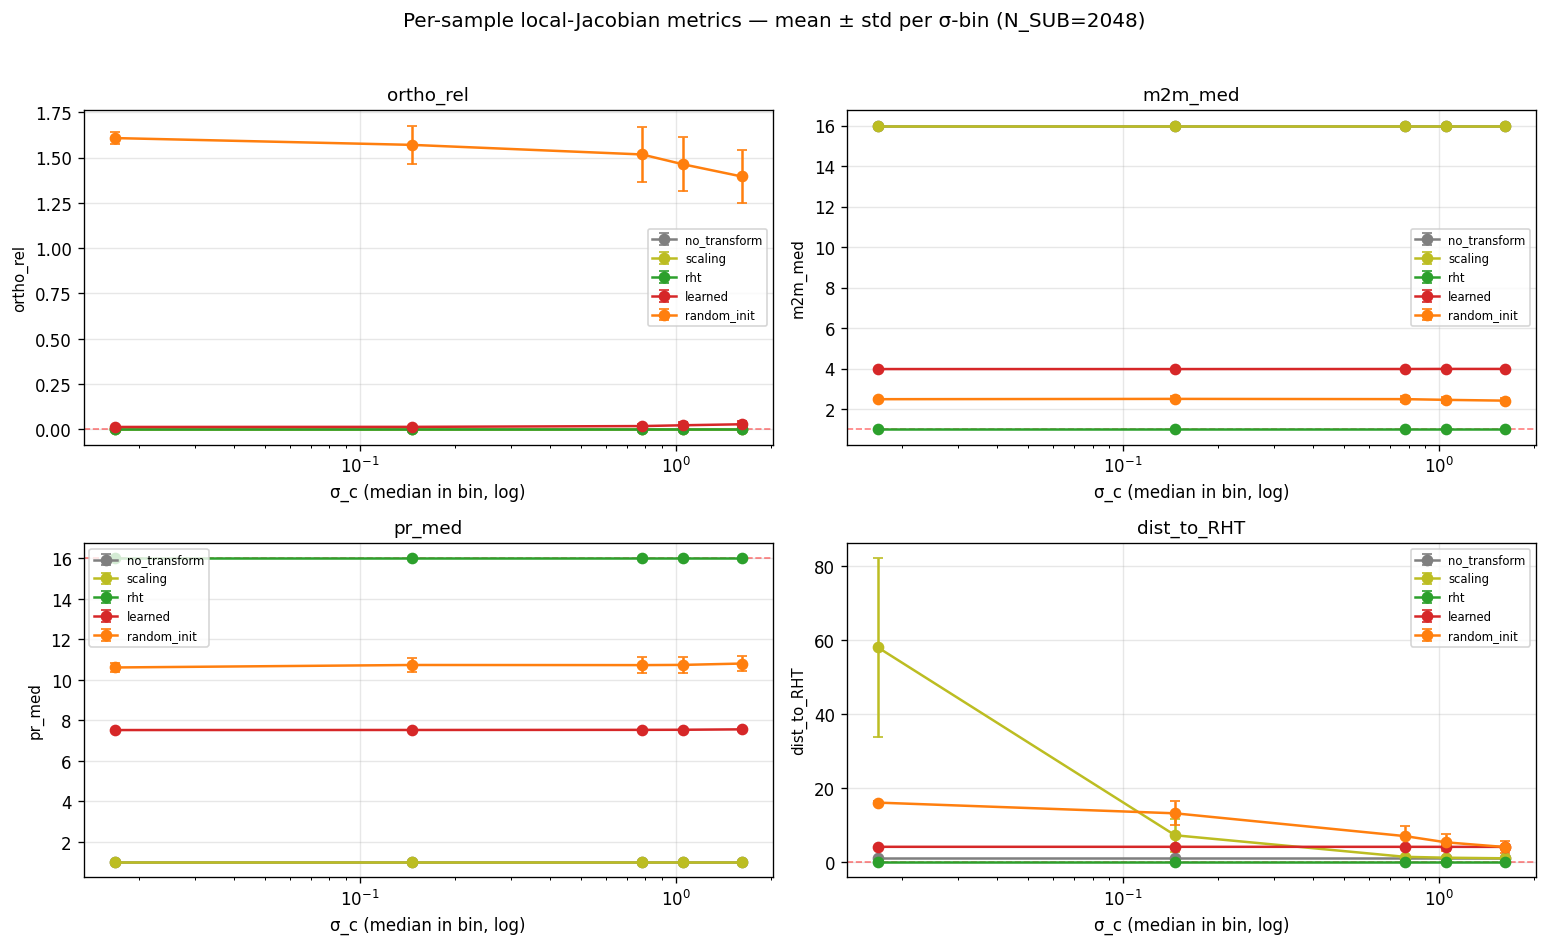

In [26]:
# 14b. Plot — 4 metrics vs σ-bin, error bars = within-bin per-sample std.
fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=120)
for ax, mname, ref in zip(axes.flatten(), metric_cols, metric_refs):
    for tname in names_order:
        sub = df_psbin[df_psbin['transform'] == tname].sort_values('sigma_mid')
        if len(sub) == 0:
            continue
        ax.errorbar(sub['sigma_mid'], sub[f'{mname}_mean'],
                    yerr=sub[f'{mname}_std'],
                    marker='o', linewidth=1.5, capsize=3,
                    color=color_map.get(tname, 'C0'), label=tname)
    ax.axhline(ref, color='red', ls='--', alpha=0.5, linewidth=1.0)
    ax.set_xscale('log')
    ax.set_xlabel('σ_c (median in bin, log)')
    ax.set_ylabel(mname, fontsize=9)
    ax.set_title(mname, fontsize=11)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
fig.suptitle(f'Per-sample local-Jacobian metrics — mean ± std per σ-bin (N_SUB={N_SUB})',
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'fig14a_per_sample_per_sigma.png'); plt.show()

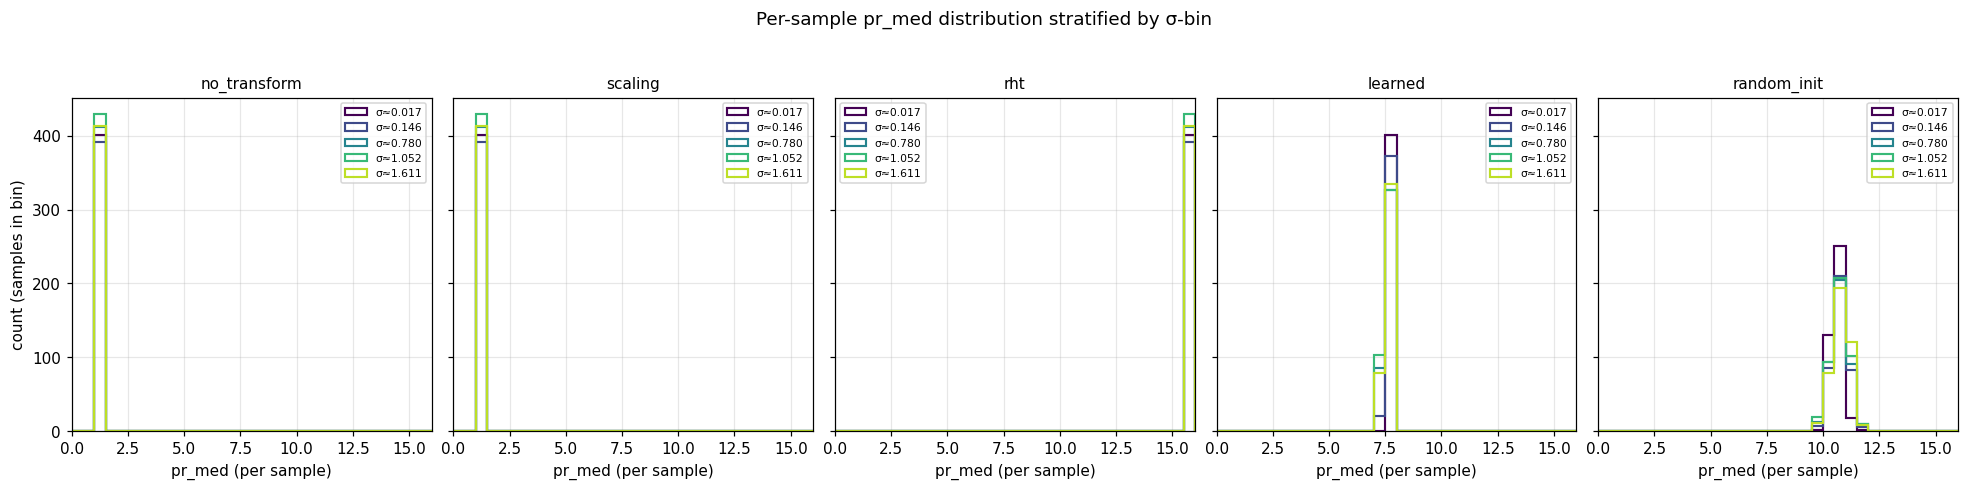

In [27]:
# 14c. Per-sample pr_med histogram per σ-bin × transform.
fig, axes = plt.subplots(1, len(names_order),
                          figsize=(3.6*len(names_order), 4.5), dpi=110, sharey=True)
PR_BINS_FINE = np.linspace(0, BLOCK_DIM, 33)
for c, tname in enumerate(names_order):
    ax = axes[c]
    pr_arr = per_sample_metrics[tname][:, 2]                                 # pr_med per sample
    for b in range(N_BINS):
        mask = bin_idx_sub == b
        if not mask.any():
            continue
        s_mid = float(sigma_per_block[bin_idx == b].median())
        ax.hist(pr_arr[mask], bins=PR_BINS_FINE,
                histtype='step', linewidth=1.4,
                color=bin_colors[b], label=f'σ≈{s_mid:.3f}')
    ax.set_xlabel('pr_med (per sample)')
    if c == 0:
        ax.set_ylabel('count (samples in bin)')
    ax.set_title(tname, fontsize=10)
    ax.set_xlim(0, BLOCK_DIM)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
fig.suptitle('Per-sample pr_med distribution stratified by σ-bin', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG_DIR / 'fig14b_pr_per_sample_per_sigma.png'); plt.show()

## 15. Highest-σ regime — focused per-sample analysis

The largest-σ columns of `W` are where the learned encoder shows the most per-sample
heterogeneity (§14: ortho_rel std ~500× higher in σ-bin 4 vs bin 0).

Two restrictions:
- **§15a/b**: top σ-bin (bin 4, σ ≈ 1.61, ~209K blocks) — subsample 2048 for per-sample J.
- **§15c/d**: TOP-1 column by σ (single largest-σ column = 256 blocks).
  Strict subset — the very tail of high-σ behaviour.

In [28]:
# 15a. Per-sample local Jacobian on samples drawn ONLY from the top σ-bin (bin 4).
TOP_BIN = N_BINS - 1                                                # 4
mask_top_bin = (bin_idx == TOP_BIN)
top_bin_pool = torch.nonzero(mask_top_bin, as_tuple=False).squeeze(-1)        # global indices
print(f'top σ-bin (bin {TOP_BIN}, σ ≈ {float(sigma_per_block[mask_top_bin].median()):.4f}) '
      f'has {len(top_bin_pool)} blocks')

N_SUB_TOP = min(2048, len(top_bin_pool))
torch.manual_seed(1)
sub_idx_top = top_bin_pool[torch.randperm(len(top_bin_pool))[:N_SUB_TOP]].to(DEVICE)
X_sub_top   = X_ALL[sub_idx_top]
sigma_sub_top = sigma_per_block.to(DEVICE)[sub_idx_top]

per_sample_metrics_top = {}
for tname, tf in TRANSFORMS.items():
    if tname == 'no_transform':
        J_batch = eye_d.unsqueeze(0).expand(N_SUB_TOP, -1, -1).contiguous()
    elif tname == 'scaling':
        g_n = (1.0 / sigma_sub_top).to(DEVICE)
        J_batch = g_n.view(-1, 1, 1) * eye_d.unsqueeze(0)
    else:
        f_single = to_single_sample(tf)
        J_list = []
        for i in range(N_SUB_TOP):
            J_list.append(compute_local_jacobian(f_single, X_sub_top[i]).detach())
        J_batch = torch.stack(J_list, 0)
    metrics = metrics_array_for_J(J_batch, J_rht_ref)
    per_sample_metrics_top[tname] = metrics.cpu().numpy()
    m_mean = metrics.mean(0).cpu().numpy()
    m_std  = metrics.std(0).cpu().numpy()
    print(f'{tname:14s}  ortho={m_mean[0]:.4f}±{m_std[0]:.4f}  '
          f'm2m={m_mean[1]:.4f}±{m_std[1]:.4f}  '
          f'pr={m_mean[2]:.4f}±{m_std[2]:.4f}  '
          f'dist={m_mean[3]:.4f}±{m_std[3]:.4f}')

rows = []
for tname in names_order:
    m = per_sample_metrics_top[tname]
    rows.append({'transform': tname,
        'ortho_rel_mean': float(m[:,0].mean()), 'ortho_rel_std': float(m[:,0].std()),
        'm2m_med_mean':   float(m[:,1].mean()), 'm2m_med_std':   float(m[:,1].std()),
        'pr_med_mean':    float(m[:,2].mean()), 'pr_med_std':    float(m[:,2].std()),
        'dist_to_RHT_mean': float(m[:,3].mean()), 'dist_to_RHT_std': float(m[:,3].std())})
df_top = pd.DataFrame(rows)
df_top.to_csv(FIG_DIR / 'fig15_top_sigma_bin_metrics.csv', index=False)
print('\nSaved → fig15_top_sigma_bin_metrics.csv')
print(df_top.round(4).to_string(index=False))

top σ-bin (bin 4, σ ≈ 1.6110) has 209664 blocks
no_transform    ortho=0.0000±0.0000  m2m=16.0000±0.0000  pr=1.0000±0.0000  dist=1.2247±0.0000
scaling         ortho=0.0000±0.0000  m2m=16.0000±0.0000  pr=1.0000±0.0000  dist=1.0322±0.0247
rht             ortho=0.0000±0.0000  m2m=1.0000±0.0000  pr=16.0000±0.0000  dist=0.0000±0.0000


KeyboardInterrupt: 

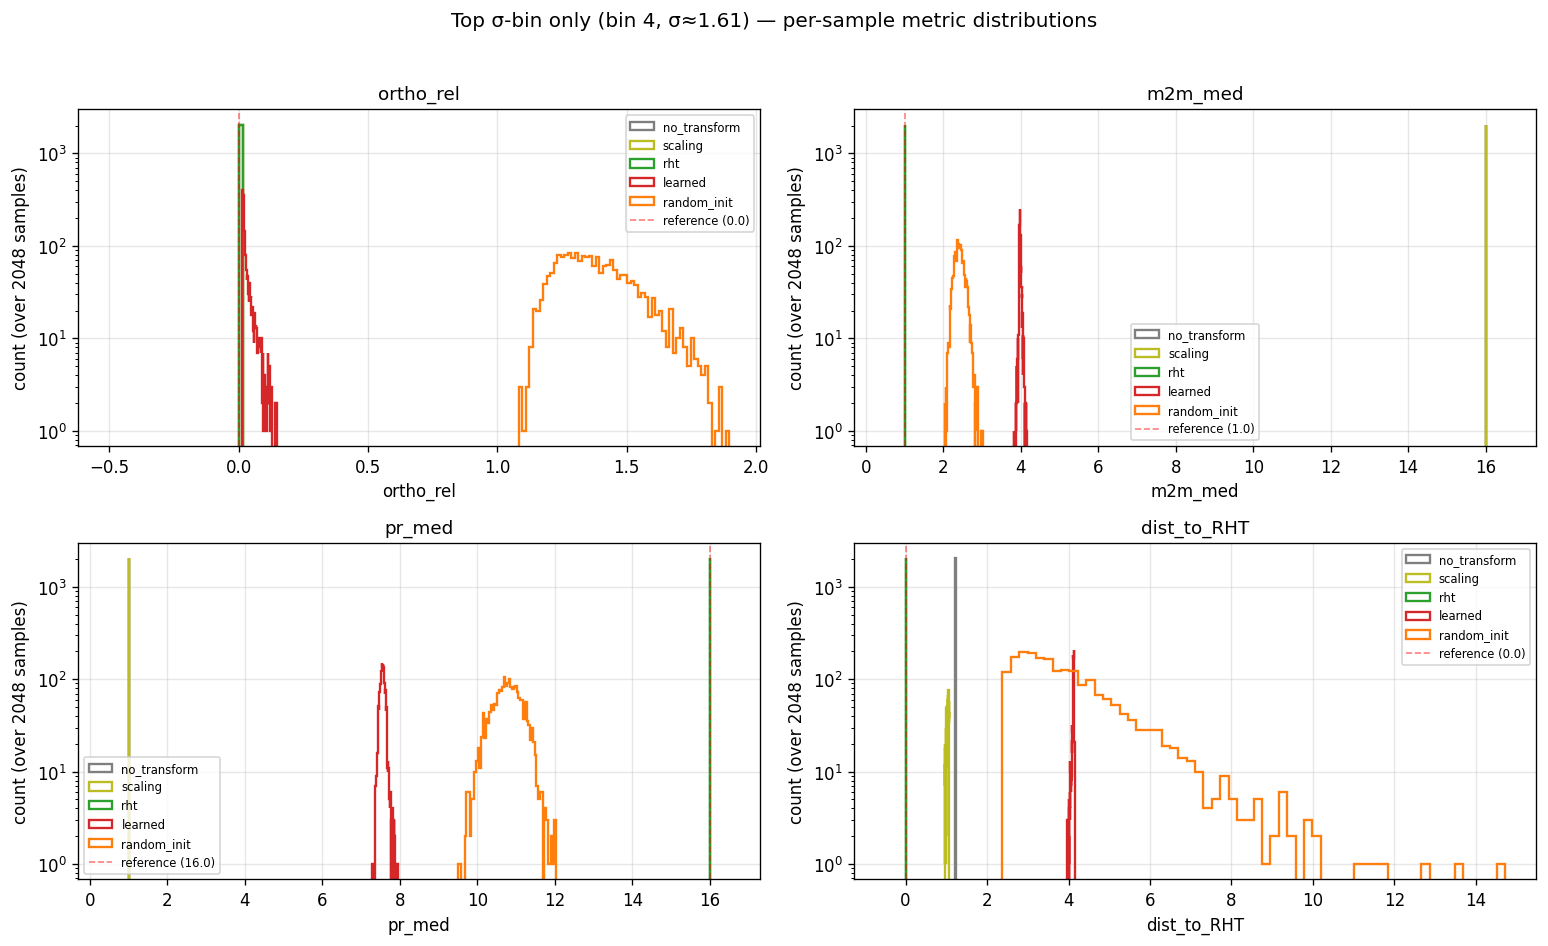

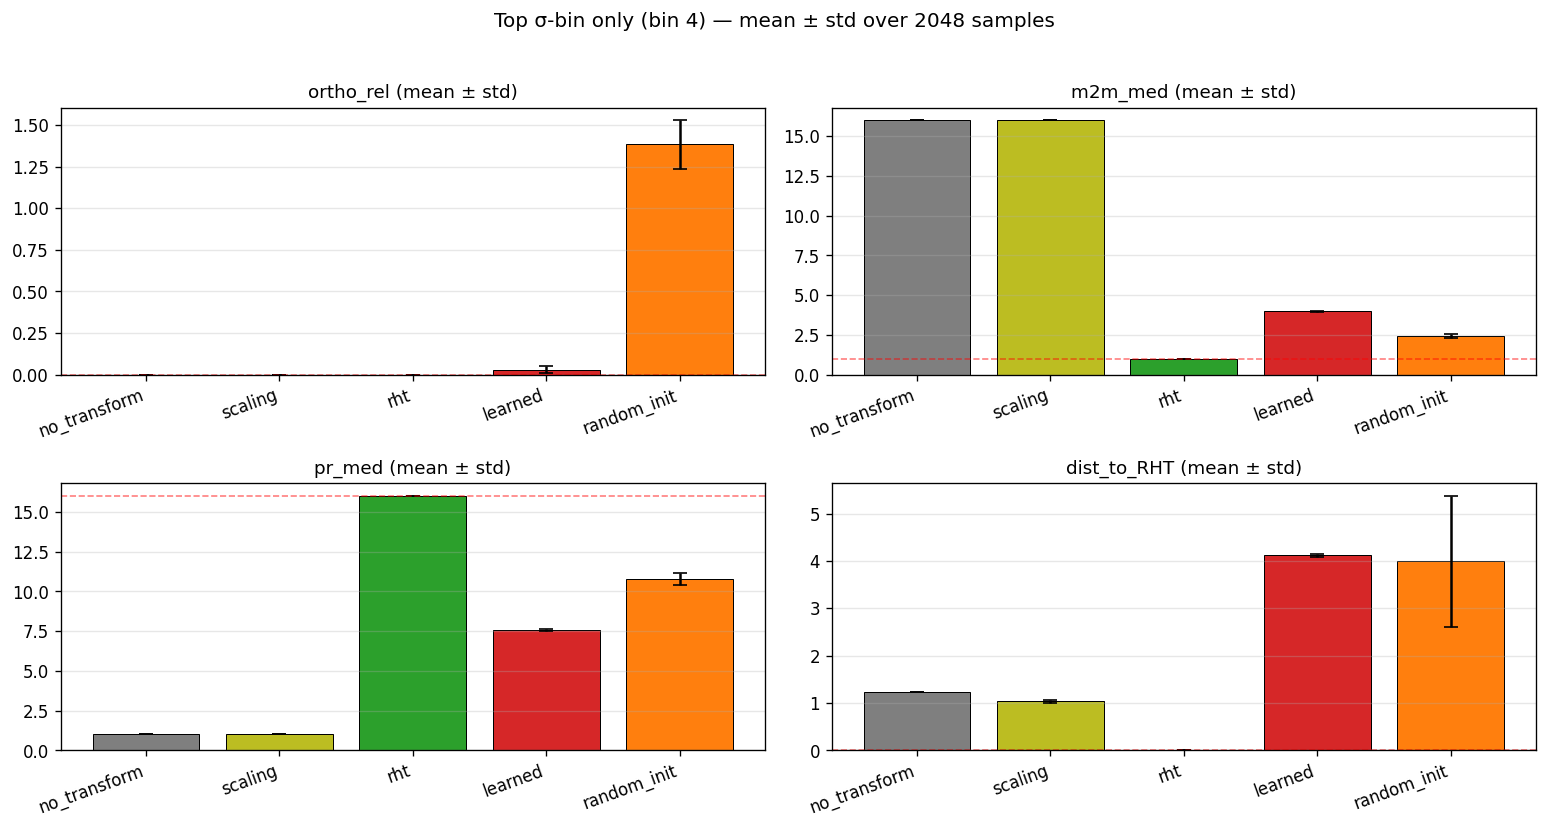

In [ ]:
# 15b. Plot — top-σ-bin per-sample metric distributions (4 hist + 4 mean±std bars).
fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=120)
for idx, (ax, mname, ref) in enumerate(zip(axes.flatten(), metric_cols, metric_refs)):
    for tname in names_order:
        vals = per_sample_metrics_top[tname][:, idx]
        ax.hist(vals, bins=60, histtype='step', linewidth=1.4,
                color=color_map.get(tname, 'C0'), label=tname)
    ax.axvline(ref, color='red', ls='--', alpha=0.5, linewidth=1.0,
               label=f'reference ({ref})')
    ax.set_xlabel(mname); ax.set_ylabel(f'count (over {N_SUB_TOP} samples)')
    ax.set_title(mname, fontsize=11); ax.set_yscale('log')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
fig.suptitle(f'Top σ-bin only (bin {TOP_BIN}, σ≈1.61) — per-sample metric distributions',
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'fig15a_top_sigma_bin_hist.png'); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 7), dpi=120)
xs = np.arange(len(names_order))
for ax, mname, ref in zip(axes.flatten(), metric_cols, metric_refs):
    means = df_top[f'{mname}_mean'].values
    stds  = df_top[f'{mname}_std'].values
    ax.bar(xs, means, yerr=stds, capsize=4,
           color=[color_map.get(t, 'C0') for t in names_order],
           edgecolor='black', linewidth=0.6)
    ax.axhline(ref, color='red', ls='--', alpha=0.5, linewidth=1.0)
    ax.set_xticks(xs); ax.set_xticklabels(names_order, rotation=20, ha='right')
    ax.set_title(f'{mname} (mean ± std)', fontsize=11)
    ax.grid(True, axis='y', alpha=0.3)
fig.suptitle(f'Top σ-bin only (bin {TOP_BIN}) — mean ± std over {N_SUB_TOP} samples',
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'fig15b_top_sigma_bin_meanstd.png'); plt.show()

In [ ]:
# 15c. Strict tail: TOP-K columns by σ.  Each column has 256 blocks.
TOP_K_COLS = 1                                                      # tune as desired
sigma_col_cpu = sigma_col.cpu()
top_col_indices = torch.argsort(sigma_col_cpu, descending=True)[:TOP_K_COLS]
print(f'Top-{TOP_K_COLS} columns by σ:  σ ∈ '
      f'[{float(sigma_col_cpu[top_col_indices[-1]]):.3f}, '
      f'{float(sigma_col_cpu[top_col_indices[0]]):.3f}]')

# Each column j contains the slice of blocks at indices [j*256, j*256+256) under our reshape.
blocks_per_col = W_full.shape[0] // BLOCK_DIM
block_pool = []
for c in top_col_indices.tolist():
    block_pool.append(torch.arange(c*blocks_per_col, (c+1)*blocks_per_col))
block_pool = torch.cat(block_pool, 0).to(DEVICE)
print(f'Block pool size: {len(block_pool)}  ({TOP_K_COLS} cols × {blocks_per_col} blocks/col)')

N_SUB_TAIL = min(2048, len(block_pool))
torch.manual_seed(2)
sub_idx_tail = block_pool[torch.randperm(len(block_pool))[:N_SUB_TAIL]]
X_sub_tail   = X_ALL[sub_idx_tail]
sigma_sub_tail = sigma_per_block.to(DEVICE)[sub_idx_tail]

per_sample_metrics_tail = {}
for tname, tf in TRANSFORMS.items():
    if tname == 'no_transform':
        J_batch = eye_d.unsqueeze(0).expand(N_SUB_TAIL, -1, -1).contiguous()
    elif tname == 'scaling':
        g_n = (1.0 / sigma_sub_tail).to(DEVICE)
        J_batch = g_n.view(-1, 1, 1) * eye_d.unsqueeze(0)
    else:
        f_single = to_single_sample(tf)
        J_list = []
        for i in range(N_SUB_TAIL):
            J_list.append(compute_local_jacobian(f_single, X_sub_tail[i]).detach())
        J_batch = torch.stack(J_list, 0)
    metrics = metrics_array_for_J(J_batch, J_rht_ref)
    per_sample_metrics_tail[tname] = metrics.cpu().numpy()
    m_mean = metrics.mean(0).cpu().numpy()
    m_std  = metrics.std(0).cpu().numpy()
    print(f'{tname:14s}  ortho={m_mean[0]:.4f}±{m_std[0]:.4f}  '
          f'm2m={m_mean[1]:.4f}±{m_std[1]:.4f}  '
          f'pr={m_mean[2]:.4f}±{m_std[2]:.4f}  '
          f'dist={m_mean[3]:.4f}±{m_std[3]:.4f}')

rows = []
for tname in names_order:
    m = per_sample_metrics_tail[tname]
    rows.append({'transform': tname,
        'ortho_rel_mean': float(m[:,0].mean()), 'ortho_rel_std': float(m[:,0].std()),
        'm2m_med_mean':   float(m[:,1].mean()), 'm2m_med_std':   float(m[:,1].std()),
        'pr_med_mean':    float(m[:,2].mean()), 'pr_med_std':    float(m[:,2].std()),
        'dist_to_RHT_mean': float(m[:,3].mean()), 'dist_to_RHT_std': float(m[:,3].std())})
df_tail = pd.DataFrame(rows)
df_tail.to_csv(FIG_DIR / 'fig15_top_K_cols_metrics.csv', index=False)
print('\nSaved → fig15_top_K_cols_metrics.csv')
print(df_tail.round(4).to_string(index=False))

Top-1 columns by σ:  σ ∈ [4.554, 4.554]
Block pool size: 256  (1 cols × 256 blocks/col)
no_transform    ortho=0.0000±0.0000  m2m=16.0000±0.0000  pr=1.0000±0.0000  dist=1.2247±0.0000
scaling         ortho=0.0000±0.0000  m2m=16.0000±0.0000  pr=1.0000±0.0000  dist=0.9687±0.0000


rht             ortho=0.0000±0.0000  m2m=1.0000±0.0000  pr=16.0000±0.0000  dist=0.0000±0.0000


learned         ortho=0.0385±0.0189  m2m=3.9549±0.0409  pr=7.6343±0.0974  dist=4.0878±0.0259


random_init     ortho=1.2317±0.0647  m2m=2.3938±0.1256  pr=10.9000±0.2955  dist=2.6495±0.3256

Saved → fig15_top_K_cols_metrics.csv
   transform  ortho_rel_mean  ortho_rel_std  m2m_med_mean  m2m_med_std  pr_med_mean  pr_med_std  dist_to_RHT_mean  dist_to_RHT_std
no_transform          0.0000         0.0000       16.0000       0.0000       1.0000      0.0000            1.2247           0.0000
     scaling          0.0000         0.0000       16.0000       0.0000       1.0000      0.0000            0.9687           0.0000
         rht          0.0000         0.0000        1.0000       0.0000      16.0000      0.0000            0.0000           0.0000
     learned          0.0385         0.0189        3.9549       0.0408       7.6343      0.0973            4.0878           0.0259
 random_init          1.2317         0.0646        2.3938       0.1253      10.9000      0.2949            2.6495           0.3250


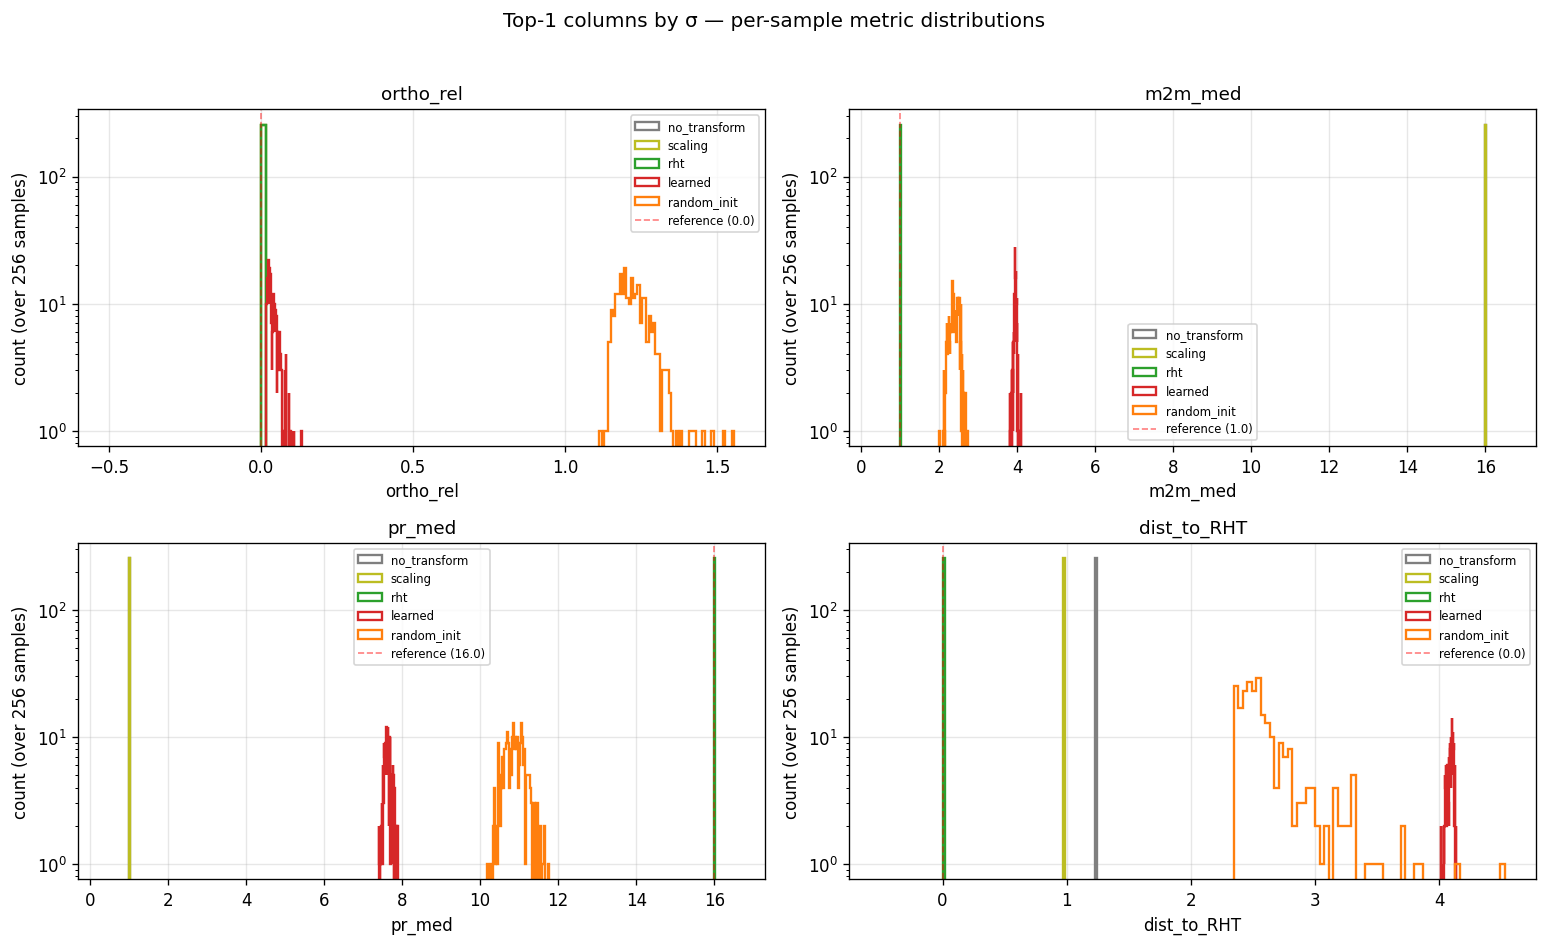

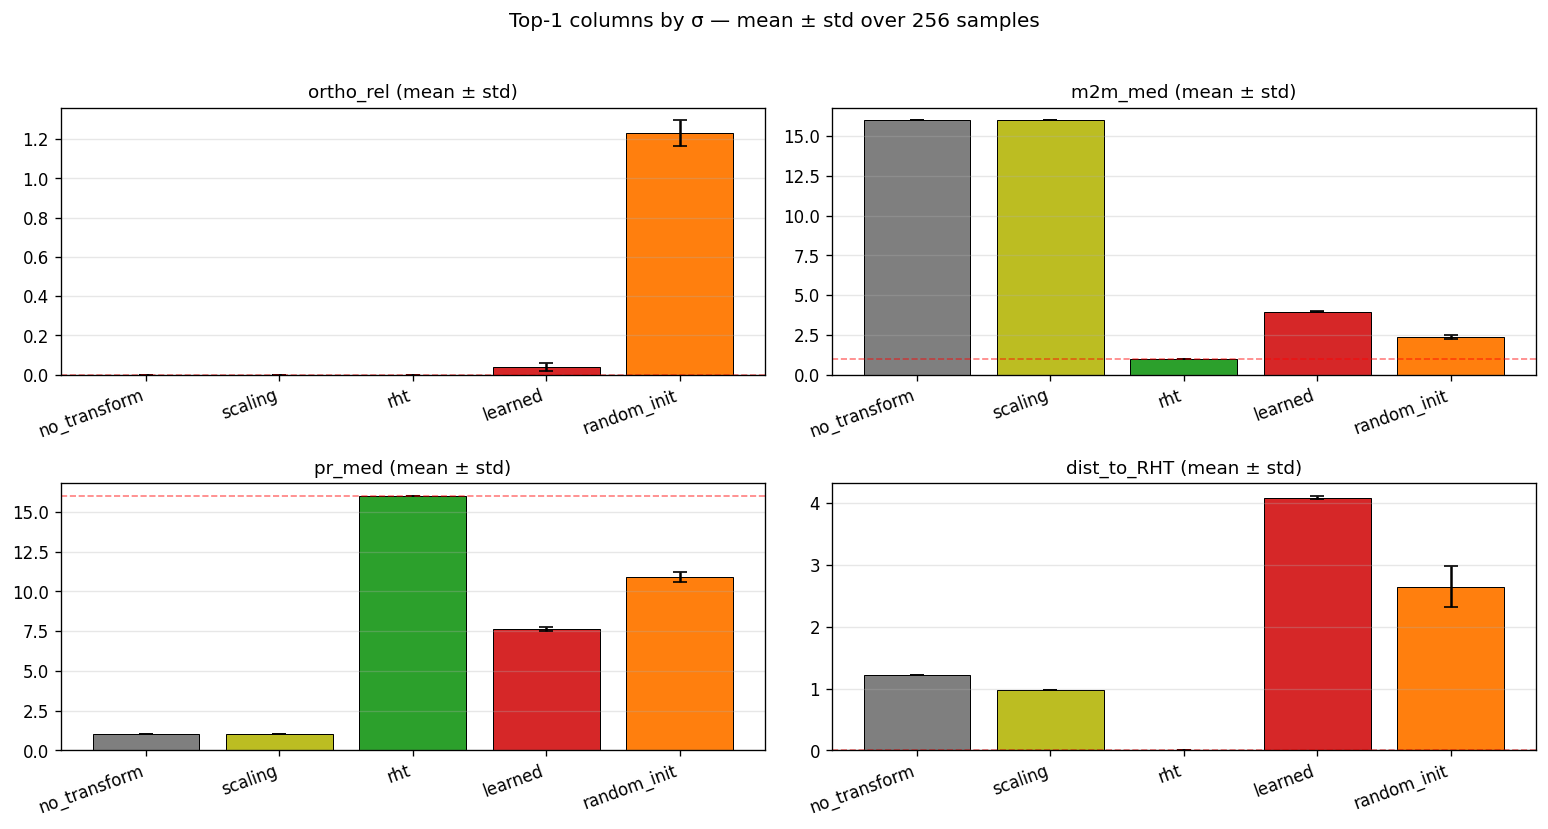

In [ ]:
# 15d. Plot — top-K-columns per-sample metrics (hist + bar).
fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=120)
for idx, (ax, mname, ref) in enumerate(zip(axes.flatten(), metric_cols, metric_refs)):
    for tname in names_order:
        vals = per_sample_metrics_tail[tname][:, idx]
        ax.hist(vals, bins=60, histtype='step', linewidth=1.4,
                color=color_map.get(tname, 'C0'), label=tname)
    ax.axvline(ref, color='red', ls='--', alpha=0.5, linewidth=1.0,
               label=f'reference ({ref})')
    ax.set_xlabel(mname); ax.set_ylabel(f'count (over {N_SUB_TAIL} samples)')
    ax.set_title(mname, fontsize=11); ax.set_yscale('log')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
fig.suptitle(f'Top-{TOP_K_COLS} columns by σ — per-sample metric distributions', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'fig15c_top_K_cols_hist.png'); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 7), dpi=120)
xs = np.arange(len(names_order))
for ax, mname, ref in zip(axes.flatten(), metric_cols, metric_refs):
    means = df_tail[f'{mname}_mean'].values
    stds  = df_tail[f'{mname}_std'].values
    ax.bar(xs, means, yerr=stds, capsize=4,
           color=[color_map.get(t, 'C0') for t in names_order],
           edgecolor='black', linewidth=0.6)
    ax.axhline(ref, color='red', ls='--', alpha=0.5, linewidth=1.0)
    ax.set_xticks(xs); ax.set_xticklabels(names_order, rotation=20, ha='right')
    ax.set_title(f'{mname} (mean ± std)', fontsize=11)
    ax.grid(True, axis='y', alpha=0.3)
fig.suptitle(f'Top-{TOP_K_COLS} columns by σ — mean ± std over {N_SUB_TAIL} samples',
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'fig15d_top_K_cols_meanstd.png'); plt.show()

## 16. Scale-invariant variants of `dist_to_RHT`

The original metric
$$d(J) = \frac{\| |J| - |J_{rht}| \|_F}{\|J_{rht}\|_F}$$
mixes two effects:
- **Shape (pattern) difference** — does the |J| have the RHT-style uniform-magnitude entries?
- **Scale difference** — `‖J‖_F` of the learned encoder ≈ 19, of identity ≈ 4, of RHT ≈ 4.
  A 5× scale gap alone produces a large Frobenius distance even if the *pattern* is identical.

Three scale-invariant variants:

1. **Unit-norm distance**
$$d_{u}(J) = \Big\| \tfrac{|J|}{\|J\|_F} - \tfrac{|J_{rht}|}{\|J_{rht}\|_F} \Big\|_F$$
Purely shape: each matrix scaled to unit Frobenius norm.

2. **Best-α distance** (LSQ fit a scalar α so that `|J|` ≈ α·`|J_rht|`)
$$\alpha^* = \frac{\langle |J|, |J_{rht}|\rangle}{\|J_{rht}\|_F^2}, \quad
  d_{\alpha}(J) = \frac{\| |J| - \alpha^*|J_{rht}| \|_F}{\|J\|_F}$$
Allows arbitrary scaling of RHT; remaining residual is pure shape mismatch.

3. **Cosine-similarity-based**
$$d_{\cos}(J) = 1 - \frac{\langle |J|, |J_{rht}|\rangle}{\|J\|_F \cdot \|J_{rht}\|_F}$$
Shape-only, bounded in [0, 2].

In [ ]:
# 16a. Define scale-invariant variants and compute for global empirical J.
@torch.no_grad()
def dist_to_rht_unit(J, J_rht):
    Ja = J.abs() / torch.linalg.norm(J).clamp_min(1e-12)
    Ra = J_rht.abs() / torch.linalg.norm(J_rht).clamp_min(1e-12)
    return float(torch.linalg.norm(Ja - Ra))

@torch.no_grad()
def dist_to_rht_alpha(J, J_rht):
    A = J.abs(); R = J_rht.abs()
    alpha = (A * R).sum() / (R * R).sum().clamp_min(1e-12)
    return float(torch.linalg.norm(A - alpha * R) / torch.linalg.norm(A).clamp_min(1e-12)), float(alpha)

@torch.no_grad()
def dist_to_rht_cos(J, J_rht):
    A = J.abs(); R = J_rht.abs()
    num = (A * R).sum()
    den = (torch.linalg.norm(A) * torch.linalg.norm(R)).clamp_min(1e-12)
    return float(1.0 - num / den)

J_rht_g = JACOBIANS_EMP['rht']
print(f"{'transform':<14}  {'orig':>9}  {'unit':>9}  {'alpha':>9}  {'α*':>7}  {'cos':>9}  {'‖J‖_F':>7}")
for tn, J in JACOBIANS_EMP.items():
    d_orig  = dist_to_rht(J, J_rht_g)
    d_unit  = dist_to_rht_unit(J, J_rht_g)
    d_alpha, alpha = dist_to_rht_alpha(J, J_rht_g)
    d_cos   = dist_to_rht_cos(J, J_rht_g)
    print(f'{tn:<14}  {d_orig:>9.4f}  {d_unit:>9.4f}  {d_alpha:>9.4f}  {alpha:>7.3f}  '
          f'{d_cos:>9.4f}  {float(torch.linalg.norm(J)):>7.3f}')

transform            orig       unit      alpha       α*        cos    ‖J‖_F
no_transform       1.2247     1.2247     0.9682    0.250     0.7500    4.000
scaling            1.0872     1.2096     0.9633    0.207     0.7315    3.090
rht                0.0000     0.0000     0.0000    1.000     0.0000    4.000
learned            4.1101     0.7909     0.7265    3.252     0.3128   18.931
random_init        2.9123     0.5702     0.5465    3.097     0.1626   14.792


In [ ]:
# 16b. Per-sample (top σ-bin) — compare original vs unit-norm dist.
def metrics_array_with_invariant(J_batch, J_rht_ref):
    """Compute [ortho_rel, m2m_med, pr_med, dist_to_RHT_orig, dist_to_RHT_unit,
       dist_to_RHT_cos] per sample; (B, 6)."""
    base = metrics_array_for_J(J_batch, J_rht_ref)                       # (B, 4)
    # unit-norm
    A = J_batch.abs()
    norm_J   = torch.linalg.norm(J_batch.reshape(J_batch.shape[0], -1), dim=-1).clamp_min(1e-12)
    norm_R   = torch.linalg.norm(J_rht_ref).clamp_min(1e-12)
    A_unit   = A / norm_J.view(-1, 1, 1)
    R_unit   = J_rht_ref.abs() / norm_R
    d_unit   = torch.linalg.norm((A_unit - R_unit.unsqueeze(0)).reshape(A.shape[0], -1), dim=-1)
    # cos
    A_flat = A.reshape(A.shape[0], -1)
    R_flat = J_rht_ref.abs().reshape(-1)
    num    = A_flat @ R_flat
    d_cos  = 1.0 - num / (norm_J * torch.linalg.norm(R_flat))
    return torch.stack([base[:, 0], base[:, 1], base[:, 2], base[:, 3], d_unit, d_cos], dim=-1)

# Recompute on top σ-bin sub samples
per_sample_metrics_top_v2 = {}
for tname, tf in TRANSFORMS.items():
    if tname == 'no_transform':
        J_batch = eye_d.unsqueeze(0).expand(N_SUB_TOP, -1, -1).contiguous()
    elif tname == 'scaling':
        g_n = (1.0 / sigma_sub_top).to(DEVICE)
        J_batch = g_n.view(-1, 1, 1) * eye_d.unsqueeze(0)
    else:
        f_single = to_single_sample(tf)
        J_list = [compute_local_jacobian(f_single, X_sub_top[i]).detach() for i in range(N_SUB_TOP)]
        J_batch = torch.stack(J_list, 0)
    metrics = metrics_array_with_invariant(J_batch, J_rht_ref)
    per_sample_metrics_top_v2[tname] = metrics.cpu().numpy()

# Print summary
cols = ['ortho_rel', 'm2m_med', 'pr_med', 'dist_orig', 'dist_unit', 'dist_cos']
print(f"{'transform':<14}  " + '  '.join(f'{c:>9}' for c in cols))
for tname in names_order:
    m = per_sample_metrics_top_v2[tname]
    means = m.mean(0); stds = m.std(0)
    print(f'{tname:<14}  ' + '  '.join(f'{means[i]:>4.3f}±{stds[i]:>4.3f}' for i in range(6)))

# Save CSV
import pandas as pd
rows = []
for tname in names_order:
    m = per_sample_metrics_top_v2[tname]
    rows.append({'transform': tname,
        **{f'{c}_mean': float(m[:, i].mean()) for i, c in enumerate(cols)},
        **{f'{c}_std':  float(m[:, i].std())  for i, c in enumerate(cols)}})
df_v2 = pd.DataFrame(rows)
df_v2.to_csv(FIG_DIR / 'fig16_dist_invariants.csv', index=False)
print('\nSaved → fig16_dist_invariants.csv')

transform       ortho_rel    m2m_med     pr_med  dist_orig  dist_unit   dist_cos
no_transform    0.000±0.000  16.000±0.000  1.000±0.000  1.225±0.000  1.225±0.000  0.750±0.000
scaling         0.000±0.000  16.000±0.000  1.000±0.000  1.032±0.025  1.225±0.000  0.750±0.000
rht             0.000±0.000  1.000±0.000  16.000±0.000  0.000±0.000  0.000±0.000  0.000±0.000
learned         0.030±0.021  3.984±0.030  7.557±0.075  4.115±0.025  0.791±0.002  0.313±0.002
random_init     1.383±0.145  2.419±0.138  10.777±0.385  3.991±1.381  0.621±0.022  0.193±0.014

Saved → fig16_dist_invariants.csv


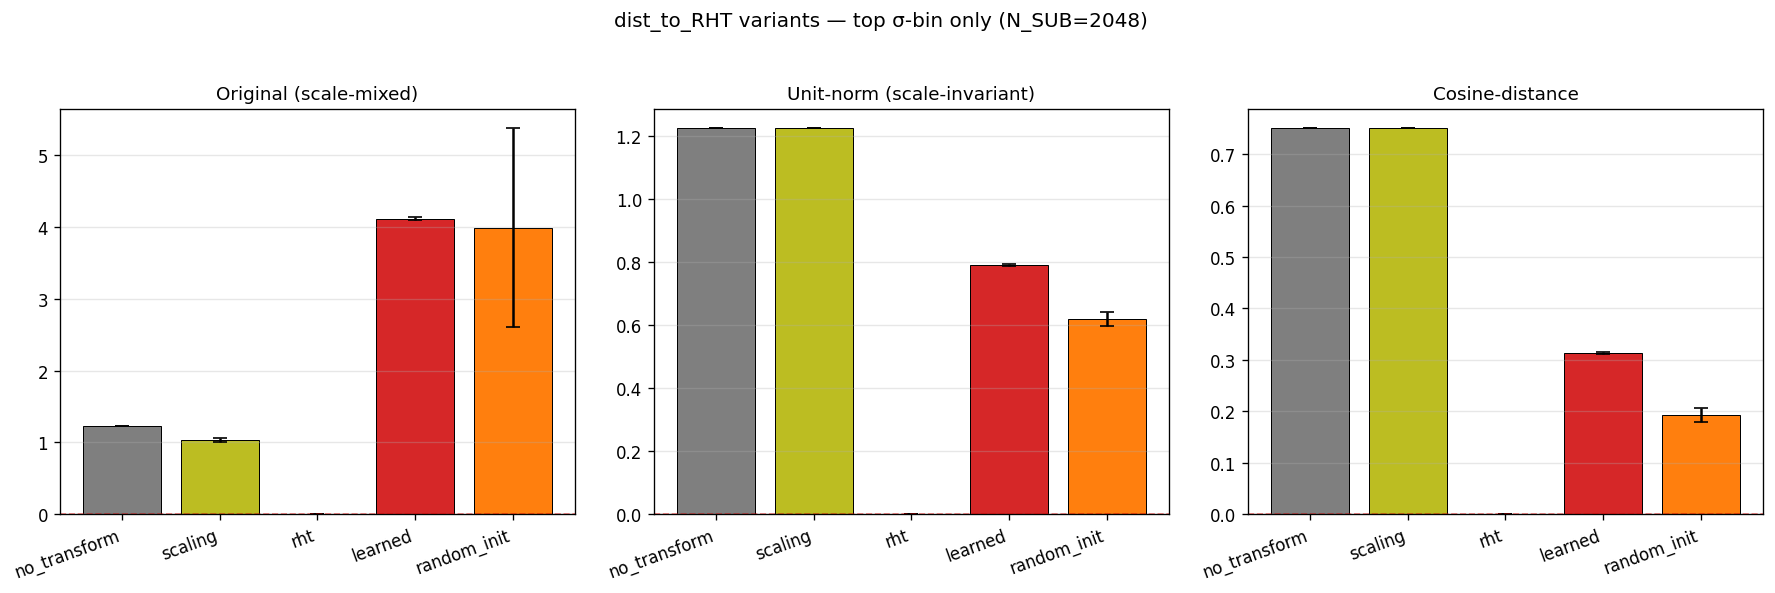

In [ ]:
# 16c. Plot — bar chart of orig vs unit vs cos, side by side.
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=120)
xs = np.arange(len(names_order))
for ax, key, ref, title in [
    (axes[0], 'dist_orig', 0.0, 'Original (scale-mixed)'),
    (axes[1], 'dist_unit', 0.0, 'Unit-norm (scale-invariant)'),
    (axes[2], 'dist_cos',  0.0, 'Cosine-distance')]:
    means = df_v2[f'{key}_mean'].values
    stds  = df_v2[f'{key}_std'].values
    ax.bar(xs, means, yerr=stds, capsize=4,
           color=[color_map.get(t, 'C0') for t in names_order],
           edgecolor='black', linewidth=0.6)
    ax.axhline(ref, color='red', ls='--', alpha=0.5, linewidth=1.0)
    ax.set_xticks(xs); ax.set_xticklabels(names_order, rotation=20, ha='right')
    ax.set_title(title, fontsize=11); ax.grid(True, axis='y', alpha=0.3)
fig.suptitle(f'dist_to_RHT variants — top σ-bin only (N_SUB={N_SUB_TOP})', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG_DIR / 'fig16_dist_invariants.png'); plt.show()